**MAIN GOAL**

To identify which ecosystem process (ET, WUE, NPP, Carbon) shows the earliest and most robust signs of loss of resilience under increased drought frequency in the Amazon.


| Bloco                                                             | Objetivo principal                                                                 | Perguntas que responde                                                                                         | Métodos / análises                                                                                                                                                                                                                                                                                                           | Principais outputs                                                                                                                                                                                                                                                                                                                                                                                           |
| ----------------------------------------------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **A – Early-warning signals (EWS)**                               | Detectar **perda de resiliência antes das quebras**                                | Existe perda de resiliência nas séries? Qual variável começa a perder resiliência primeiro?                    | - Detrending (GAM + STL/LOESS)<br> - Cálculo em janelas móveis de: **AR(1)**, **variância**, **coeficiente de variação (CV)**, **skewness**, **kurtosis**, **spectral reddening**<br> - Testes de tendência (Kendall τ, Sen slope) para cada EWS                                                                             | - Séries temporais de todos os EWS (por variável e cenário)<br> - Tabela com τ, p-value e **ano de início** do aumento de cada EWS<br> - **Ranking de variáveis** que dão sinal mais cedo (por cenário)                                                                                                                                                                                                      |
| **B – Breakpoints clássicos (sua análise original, fortalecida)** | Identificar **momentos de mudança estrutural** nas séries                          | Quando o sistema muda de regime em termos de média/tendência? As variáveis mudam no mesmo momento?             | - Métodos de **detecção de breakpoints em séries univariadas** (p.ex. `strucchange`, PELT, regressão segmentada simples)<br> - Aplicar o mesmo método a todas as variáveis e cenários<br> - Comparar posição dos breakpoints entre variáveis                                                                                 | - Ano(s) de breakpoint por variável e cenário<br> - Intervalos de confiança / incerteza desses anos (se disponível)<br> - Comparação direta: qual variável “quebra” primeiro em termos estruturais                                                                                                                                                                                                           |
| **C – Converging evidence em mudanças de tendência**              | Ver se os padrões de mudança são robustos a **múltiplos métodos**, incluindo o seu | As datas de mudança dependem do método? Tendência e sazonalidade contam a mesma história?                      | - **BFAST** (quebras em tendência + sazonalidade; se tiver dados mensais)<br> - **STL + trend filtering** na componente de tendência<br> - **Modelos state-space / Kalman** (local level / local linear trend) para tendências contínuas<br> - Comparar esses métodos com os **breakpoints clássicos do Bloco B**            | - Anos de breakpoints por BFAST<br> - Anos de mudanças de inclinação da tendência (trend filtering)<br> - Séries de tendência suavizada (state-space) e possíveis mudanças de regime<br> - Comparação entre métodos, mostrando se os breakpoints clássicos são robustos                                                                                                                                      |
| **D – Causalidade temporal (VAR / Granger / VAR-LASSO)**          | Entender **ordem temporal e influência entre processos**                           | ET/WUE antecipam NPP e Carbono? Quem dirige a dinâmica do sistema?                                             | - Construção de matrizes multivariadas (ET, WUE, NPP, Carbon) por cenário<br> - Modelos **VAR(p)** com seleção de ordem via AIC/BIC<br> - **Granger causality** para todos os pares X → Y<br> - **VAR-LASSO** para checar robustez da estrutura causal                                                                       | - Matriz de p-values de Granger (quem causa quem)<br> - Grafo causal (setas ET → NPP, etc.) por cenário<br> - Medidas de “out-degree” (quantas variáveis cada uma influencia)<br> - Comparação com ranking de EWS (A) e com o timing dos breakpoints (B–C)                                                                                                                                                   |
| **E – Critical transition timing & síntese avançada**             | Estimar **timing das transições com incerteza** e integrar todas as evidências     | Quando a transição ocorre (com IC)? Quando ela teria sido detectada “online”? O que tudo isso diz em conjunto? | - **Bayesian change point detection** (ex.: `bcp`, `mcp`) para cada série<br> - **Piecewise regression** com breakpoint(s) + incerteza (IC / bootstrap)<br> - **SPRT / CUSUM** para detecção “online” do primeiro desvio<br> - Integração com EWS (A), breakpoints clássicos (B), métodos de tendência (C) e causalidade (D) | - Breakpoints Bayesianos com **intervalos de credibilidade**<br> - Breakpoints frequentistas (piecewise) com IC<br> - Ano em que SPRT/CUSUM detecta mudança para cada variável (detecção “online”)<br> - **Linha do tempo integrada** por variável: início de EWS → detecção online → breakpoints (clássicos e bayesianos)<br> - Conclusão final sobre **quais processos são leading indicators** de colapso |


**A) EARLY WARNING SIGNALS**

*A.1 - Organizing data*


In [4]:
library(dplyr)
library(tidyr)
library(mgcv)
library(ggplot2)


Anexando pacote: 'dplyr'


Os seguintes objetos s~ao mascarados por 'package:stats':

    filter, lag


Os seguintes objetos s~ao mascarados por 'package:base':

    intersect, setdiff, setequal, union


Carregando pacotes exigidos: nlme


Anexando pacote: 'nlme'


O seguinte objeto 'e mascarado por 'package:dplyr':

    collapse


This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Warning message:
"pacote 'ggplot2' foi compilado no R vers~ao 4.4.3"


In [35]:
annual_data <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/yearly_grouped.csv")

annual_long <- annual_data %>%
  rename(
    Year     = date,
    Scenario = frequency
  ) %>%
  select(Year, Scenario, npp, ctotal, evapm, wue) %>%
  # Drop years where all key variables are NA (post-collapse years)
  filter(!(is.na(npp) & is.na(ctotal) & is.na(evapm) & is.na(wue))) %>%
  pivot_longer(
    cols      = c(npp, ctotal, evapm, wue),
    names_to  = "Variable",
    values_to = "Value"
  )


In [111]:
# doing the same for all the frequencies

yr_allfreq <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/analysis_2025/yearly_ecosystem_state/combined_yearly_vars.csv")

allfreq_long <- yr_allfreq %>%
  rename(
    Year     = date,
    Scenario = frequency
  ) %>%
  select(Year, Scenario, npp, ctotal, evapm) %>%
  # Drop years where all key variables are NA (post-collapse years)
  filter(!(is.na(npp) & is.na(ctotal) & is.na(evapm))) %>%
  pivot_longer(
    cols      = c(npp, ctotal, evapm),
    names_to  = "Variable",
    values_to = "Value"
  )

In [53]:
print(unique(annual_long$Scenario))

ERROR: Error: objeto 'annual_long' n~ao encontrado


In [54]:
print(unique(allfreq_long$Scenario))

[1] "2y"      "4y"      "6y"      "8y"      "regclim"


Detrending time series with GAM

In [37]:
#This code removes long-term temporal trends from annual model outputs using Generalized Additive Models (GAMs).
#For each combination of Scenario and Variable, a GAM is fitted with Year as a smooth predictor and the variable 
#value as the response. The smooth term captures the low-frequency (long-term) trend over time. 
#The residuals from this model represent the interannual variability after detrending and are stored as a new 
#column (residuals) in the dataset. The detrending is applied independently to each scenario–variable pair to 
#avoid mixing trends across different model configurations or output variables.

detrend_with_gam <- function(df) {
  # df must have Year and Value
  fit <- gam(Value ~ s(Year, k = 10), data = df)
  df$residuals <- residuals(fit)
  df
}

annual_detrended <- annual_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ detrend_with_gam(.x)) %>%
  ungroup()

In [29]:
# same with all freq
detrend_with_gam <- function(df) {
  # df must have Year and Value
  fit <- gam(Value ~ s(Year, k = 10), data = df)
  df$residuals <- residuals(fit)
  df
}

annual_detrended_allfreq <- allfreq_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ detrend_with_gam(.x)) %>%
  ungroup()

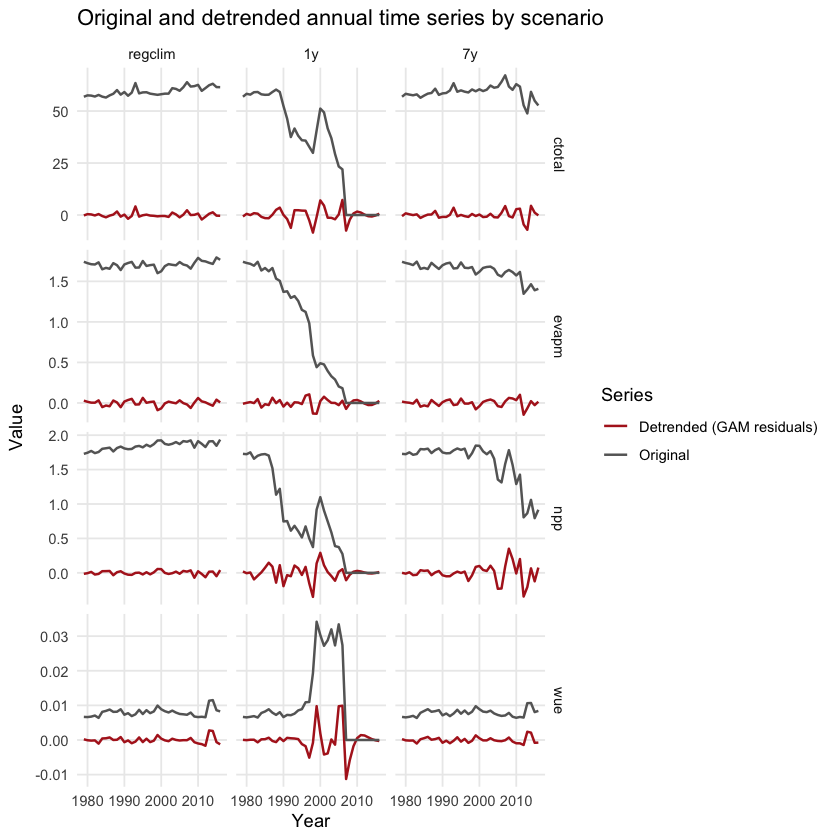

In [38]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Choose the scenarios you want to compare
scenarios_to_plot <- c("regclim", "1y", "7y")

annual_detrended %>%
  filter(Scenario %in% scenarios_to_plot) %>%
  # Put original and detrended values in long format for nicer plotting + legend
  pivot_longer(
    cols = c(Value, residuals),
    names_to = "Series",
    values_to = "TS_value"
  ) %>%
  mutate(
    # Nice labels for legend
    Series = recode(Series,
                    Value = "Original",
                    residuals = "Detrended (GAM residuals)"),
    # Optional: order scenarios in a meaningful way
    Scenario = factor(Scenario, levels = scenarios_to_plot)
  ) %>%
  ggplot(aes(x = Year, y = TS_value, color = Series)) +
  geom_line(linewidth = 0.7) +
  facet_grid(Variable ~ Scenario, scales = "free_y") +
  labs(
    x = "Year",
    y = "Value",
    title = "Original and detrended annual time series by scenario",
    color = "Series"
  ) +
  scale_color_manual(
    values = c("Original" = "grey40",
               "Detrended (GAM residuals)" = "firebrick")
  ) +
  theme_minimal() +
  theme(
    strip.background = element_blank(),
    panel.grid.minor = element_blank()
  )


Interpretation of detrended annual time series

The detrending procedure based on Generalized Additive Models (GAMs) successfully isolates the low-frequency temporal component of the annual time series. For all variables and scenarios, the residuals are centered around zero and preserve the interannual variability, indicating that the GAM smooth captures the long-term trend while removing systematic temporal structure from the residuals.

Clear differences emerge among the climate scenarios. The regclim and 7y scenarios exhibit relatively smooth long-term trajectories, with moderate interannual variability and comparable residual magnitudes across variables. In these scenarios, the detrended series can be interpreted as stationary interannual anomalies, suggesting that the system remains dynamically stable over most of the simulation period.

In contrast, the 1y scenario displays pronounced non-stationary behavior. All variables show abrupt declines and strong departures from their previous trajectories, consistent with a regime shift or systemic collapse in the modeled ecosystem. In this case, the GAM smooth is unable to fully capture the abrupt transition, resulting in substantially larger residual amplitudes. Consequently, the detrended series in the 1y scenario reflects not only interannual variability but also signals associated with structural instability of the system.

The comparison between scenarios suggests that increased climate forcing first manifests as enhanced variability (as observed in the 7y scenario) before leading to an abrupt loss of system stability under the most extreme forcing (1y). The marked increase in residual variance preceding and during the transition in the 1y scenario is consistent with theoretical expectations of resilience loss and may be interpreted as an early-warning signal of impending regime change.

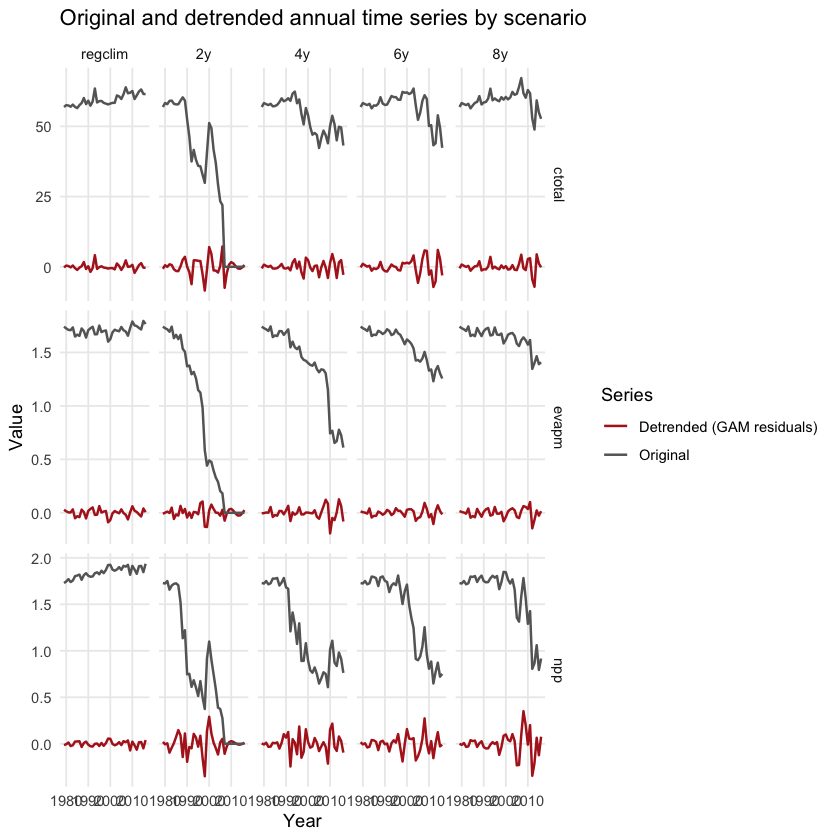

In [30]:
#doing the same for all freq

library(dplyr)
library(tidyr)
library(ggplot2)

# Choose the scenarios you want to compare
scenarios_to_plot <- c("regclim", "2y", "4y", "6y", "8y")

annual_detrended_allfreq %>%
  filter(Scenario %in% scenarios_to_plot) %>%
  # Put original and detrended values in long format for nicer plotting + legend
  pivot_longer(
    cols = c(Value, residuals),
    names_to = "Series",
    values_to = "TS_value"
  ) %>%
  mutate(
    # Nice labels for legend
    Series = recode(Series,
                    Value = "Original",
                    residuals = "Detrended (GAM residuals)"),
    # Optional: order scenarios in a meaningful way
    Scenario = factor(Scenario, levels = scenarios_to_plot)
  ) %>%
  ggplot(aes(x = Year, y = TS_value, color = Series)) +
  geom_line(linewidth = 0.7) +
  facet_grid(Variable ~ Scenario, scales = "free_y") +
  labs(
    x = "Year",
    y = "Value",
    title = "Original and detrended annual time series by scenario",
    color = "Series"
  ) +
  scale_color_manual(
    values = c("Original" = "grey40",
               "Detrended (GAM residuals)" = "firebrick")
  ) +
  theme_minimal() +
  theme(
    strip.background = element_blank(),
    panel.grid.minor = element_blank()
  )


No seu gráfico, **cinza = série original** (nível absoluto + tendência de longo prazo) e **vermelho = resíduos do GAM** (a parte “rápida”: variação interanual depois de remover a tendência suave).

### 1) O que o vermelho “significa” exatamente

Para cada *Scenario × Variable*, o GAM estima uma curva suave ( \hat{f}(Year) ) que captura a **mudança de baixa frequência** (o “drift” de décadas, colapsos graduais, mudanças estruturais lentas).
O que você plota em vermelho é:

[
residual_t = Value_t - \hat{f}(Year_t)
]

Então:

* **Vermelho ~ 0** → aquele ano está *bem explicado* pela tendência suave.
* **Vermelho positivo** → ano “melhor que o esperado” dado o nível/trajetória de longo prazo.
* **Vermelho negativo** → ano “pior que o esperado” dado o nível/trajetória de longo prazo.
* **A amplitude do vermelho** → quanta **variabilidade interanual** sobra *independente do drift*.

> Importante: o resíduo está na **mesma unidade** do “Value”, mas agora centrado perto de zero.

---

### 2) Como ler cada painel (o jeito mais seguro)

Como você usou `scales = "free_y"`, **não compare a altura do cinza entre variáveis diferentes** (ctotal vs npp etc). Compare assim:

1. **Dentro de um mesmo painel (mesma variável + cenário)**

   * O cinza te diz **o comportamento de longo prazo** (estável? declinando? colapso?).
   * O vermelho te diz **a “nervosidade” anual** em torno disso (ruído pequeno vs grandes desvios).

2. **Entre cenários, na mesma variável (mesma linha)**

   * Compare **forma do cinza** (quando começa a queda, quão abrupta, se chega perto de zero).
   * Compare **variância do vermelho** (aumenta perto da transição? aparecem “spikes”? fica mais assimétrico?).

---

### 3) O que seu gráfico está mostrando (padrões visíveis)

**Regclim (coluna 1):**

* Cinza relativamente estável em ctotal/evapm/npp (sem queda forte).
* Vermelho pequeno e bem centrado em 0 → variabilidade interanual “normal”, sem grandes choques.

**2y (coluna 2):**

* Cinza em ctotal/evapm/npp cai de forma muito forte até ~zero (colapso/forte degradação).
* Vermelho fica grande principalmente **durante a transição** (período em que o sistema está mudando rápido).
* Depois que o cinza “gruda” perto de zero, o vermelho tende a ficar pequeno (porque não há mais dinâmica anual para variar: a tendência já “comeu” quase tudo).

**4y, 6y, 8y (colunas 3–5):**

* O cinza geralmente mostra **quedas mais tardias e/ou menos abruptas** do que em 2y.
* O vermelho costuma mostrar **picos** e aumento de variabilidade perto dos momentos em que o cinza muda de patamar (indicando anos anômalos “em cima” de uma tendência de degradação).

**wue (última linha):**

* Em 2y (e um pouco em 4y) há um **pico grande no cinza** (um evento/episódio marcante).
* No vermelho, isso aparece como um desvio muito forte (spike), porque aquele(s) ano(s) ficaram muito acima/abaixo do que a tendência suave esperaria.

---

### 4) A interpretação “ecológica/estatística” que esse detrending te permite

Depois do GAM, você consegue separar duas coisas:

* **Mudança de estado / tendência lenta (cinza)**: perda de biomassa/carbono, redução persistente de evapm/npp etc.
* **Variabilidade interanual (vermelho)**: resposta a “anos específicos” (clima extremo, sequência de eventos, ruído interno do modelo).

Isso é útil porque, por exemplo, se você quer métricas de “resiliência” baseadas em:

* variância,
* autocorrelação,
* assimetria,
* “spikes”,

você geralmente quer medir isso **na série detrended**, para não confundir “tendência de colapso” com “aumento de variabilidade”.

---

### 5) Dois alertas importantes (para sua base estatística ficar sólida)

1. **Se existe colapso forte**, o GAM pode estar usando parte do “sinal de transição” como tendência.

   * Resultado: o vermelho pode parecer “calmo” depois do colapso (o que é esperado), mas também pode **subestimar** mudanças rápidas se o smooth capturar demais.
   * Para análises de *early warning*, muitas vezes faz sentido detrendar **apenas no período pré-transição** (ou trabalhar com janelas móveis).

2. O seu `k = 10` impõe um grau de flexibilidade fixo.

   * Se `k` for pequeno demais, sobra tendência no resíduo (vermelho com drift).
   * Se `k` for grande demais, você começa a “comer” variabilidade interanual e deixar o vermelho artificialmente pequeno.
     *(Aqui o seu vermelho parece bem centrado, mas o caso 2y com quebra forte sempre merece checagem.)*

Se você quiser, eu te digo exatamente o que checar (diagnóstico do GAM, escolha de `k`, e se faz sentido usar correlação temporal tipo AR(1) nos resíduos), mas **só com esse gráfico** a leitura principal é:

* **2y** induz uma mudança de estado muito mais forte (cinza colapsa) e concentra grandes anomalias (vermelho) durante a transição;
* **regclim** é estável e tem variabilidade anual pequena;
* **4y–8y** ficam no meio termo, com quedas e “spikes” mais tardios/menos extremos, dependendo da variável.



Family: gaussian 
Link function: identity 

Formula:
Value ~ s(Year, k = 10)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  33.9080     0.5789   58.58   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
          edf Ref.df     F p-value    
s(Year) 8.312  8.869 170.4  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.976   Deviance explained = 98.1%
-REML = 115.36  Scale est. = 12.734    n = 38


Method: REML   Optimizer: outer newton
full convergence after 5 iterations.
Gradient range [-3.658849e-07,2.556628e-07]
(score 115.3586 & scale 12.73388).
Hessian positive definite, eigenvalue range [2.454984,18.85978].
Model rank =  10 / 10 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

          k'  edf k-index p-value
s(Year) 9.00 8.31    0.91    0.22


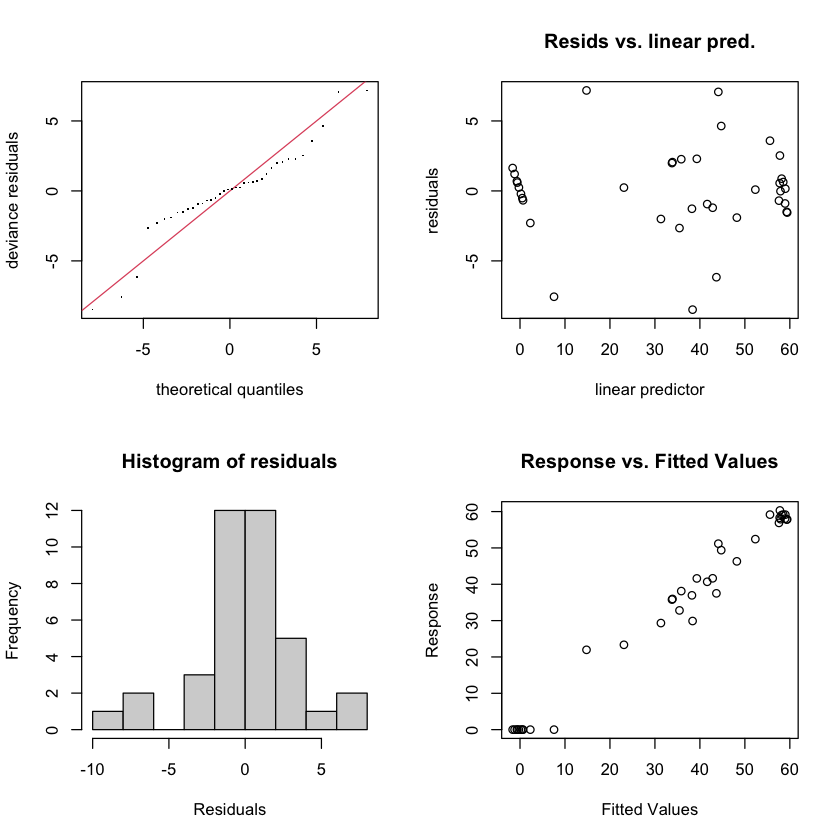

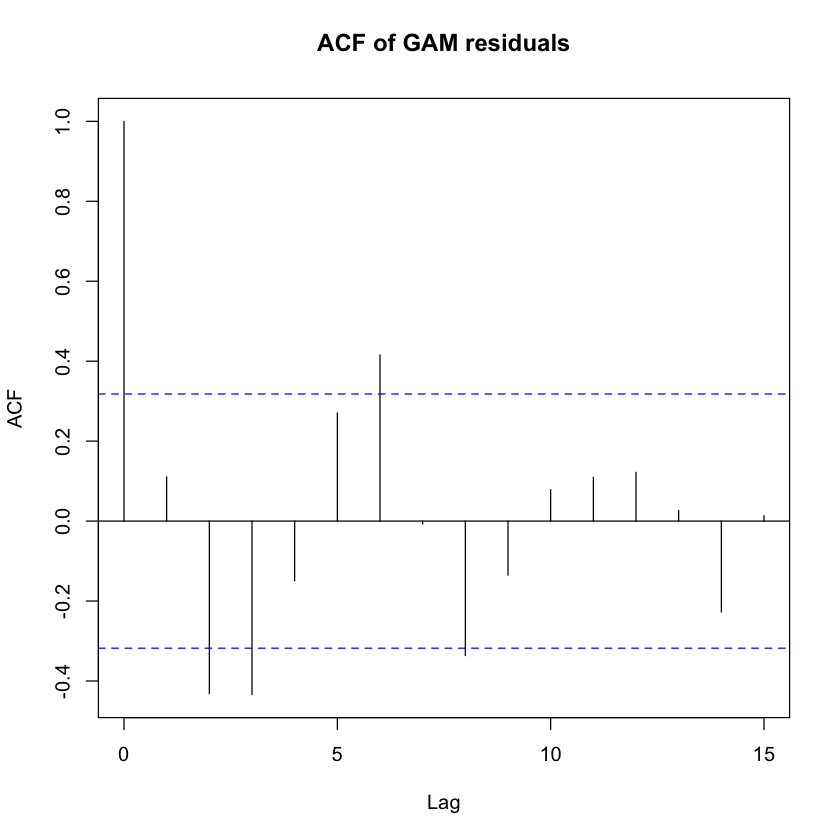

In [55]:
library(mgcv)
library(dplyr)

# Example: one scenario and one variable
df_test <- annual_detrended_allfreq %>%
  filter(Scenario == "2y", Variable == "ctotal")

fit <- gam(Value ~ s(Year, k = 10),
           data = df_test,
           method = "REML")

summary(fit)
gam.check(fit)
acf(residuals(fit), main = "ACF of GAM residuals")




*A.2 - Calculating EWS*


In [11]:
library(dplyr)
library(tidyr)
library(purrr)
library(mgcv)
library(earlywarnings)
library(Kendall)


Carregando pacotes exigidos: moments

Carregando pacotes exigidos: tgp

Carregando pacotes exigidos: tseries

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


earlywarnings Copyright (C) 2011-2022 Vasilis Dakos and Leo Lahti
http://www.early-warning-signals.org




First, we will use the residuals from the detrended TS from GAM. After, we will use the detrending from the R package earlywarnings. We will compare the differences

A.2.a. Using detrended from GAM	

In [12]:
library(e1071)  # for skewness and kurtosis
library(stats)


Anexando pacote: 'e1071'


Os seguintes objetos s~ao mascarados por 'package:moments':

    kurtosis, moment, skewness


O seguinte objeto 'e mascarado por 'package:ggplot2':

    element




In [41]:

compute_ews_window <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance
    var_x <- var(xw, na.rm = TRUE)
    
    # Coefficient of variation
    mean_x <- mean(xw, na.rm = TRUE)
    cv_x <- ifelse(abs(mean_x) < .Machine$double.eps, NA, sqrt(var_x) / mean_x)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      CV          = cv_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [37]:
#the same for all freq

compute_ews_window <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance
    var_x <- var(xw, na.rm = TRUE)
    
    # Coefficient of variation
    mean_x <- mean(xw, na.rm = TRUE)
    cv_x <- ifelse(abs(mean_x) < .Machine$double.eps, NA, sqrt(var_x) / mean_x)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      CV          = cv_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [14]:

ews_gam_manual <- annual_detrended %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window(
        x    = .x$residuals,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [38]:

ews_gam_manual_allfreq <- annual_detrended_allfreq %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window(
        x    = .x$residuals,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [40]:
print(dim(ews_gam_manual_allfreq))
print(head(ews_gam_manual_allfreq))
print(names(ews_gam_manual_allfreq))

write.csv(ews_gam_manual_allfreq, "/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/analysis_2025/yearly_ecosystem_state/ews_gam_manual_allfreq.csv", row.names = FALSE)

[1] 300   9
# A tibble: 6 x 9
# Groups:   Scenario, Variable [1]
  Scenario Variable time_center   AR1 Variance      CV Skewness Kurtosis
  <chr>    <chr>          <dbl> <dbl>    <dbl>   <dbl>    <dbl>    <dbl>
1 2y       ctotal          1988 0.200     5.23   24.2    -0.989    1.78 
2 2y       ctotal          1989 0.258     9.08   -9.61   -1.39     2.13 
3 2y       ctotal          1990 0.288     9.05   -7.66   -1.31     1.99 
4 2y       ctotal          1991 0.199    12.0  -153.     -0.612    1.49 
5 2y       ctotal          1992 0.318    13.0    21.2    -0.592    1.02 
6 2y       ctotal          1993 0.291    13.1    53.0    -0.495    0.879
# i 1 more variable: Reddening <dbl>
[1] "Scenario"    "Variable"    "time_center" "AR1"         "Variance"   
[6] "CV"          "Skewness"    "Kurtosis"    "Reddening"  


In [43]:
run_ews_gam <- function(df, winsize = 50) {
  # df must contain: Year, residuals
  
  # 1) Sort by time and remove NA residuals (e.g., post-collapse gaps)
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(residuals))
  
  # 2) If the cleaned series is too short, skip this group
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Build the time series matrix: first column = time, second = values
  ts_mat <- cbind(df_clean$Year, df_clean$residuals)
  
  # 4) Safely run generic_ews on GAM residuals
  ew <- tryCatch(
    suppressWarnings(
      generic_ews(
        timeseries    = ts_mat,
        winsize       = winsize,    # % of the available (pre-collapse) series
        detrending    = "no",       # GAM already removed the trend
        logtransform  = FALSE,
        interpolate   = FALSE,
        AR_n          = TRUE,
        powerspectrum = TRUE
      )
    ),
    error = function(e) NULL
  )
  
  if (is.null(ew)) return(NULL)
  
  as.data.frame(ew)
}


In [16]:
run_ews_gam <- function(df, winsize = 50) {
  # df must contain: Year, residuals
  
  # 1) Sort by time and remove NA residuals (e.g., post-collapse gaps)
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(residuals))
  
  # 2) If the cleaned series is too short, skip this group
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Build the time series matrix: first column = time, second = values
  ts_mat <- cbind(df_clean$Year, df_clean$residuals)
  
  # 4) Safely run generic_ews on GAM residuals
  ew <- tryCatch(
    suppressWarnings(
      generic_ews(
        timeseries    = ts_mat,
        winsize       = winsize,    # % of the available (pre-collapse) series
        detrending    = "no",       # GAM already removed the trend
        logtransform  = FALSE,
        interpolate   = FALSE,
        AR_n          = TRUE,
        powerspectrum = TRUE
      )
    ),
    error = function(e) NULL
  )
  
  if (is.null(ew)) return(NULL)
  
  as.data.frame(ew)
}


In [46]:
print(dim(ews_gam_manual))
print(head(ews_gam_manual))
print(names(ews_gam_manual))


[1] 240   9
# A tibble: 6 x 9
# Groups:   Scenario, Variable [1]
  Scenario Variable time_center   AR1 Variance      CV Skewness Kurtosis
  <chr>    <chr>          <dbl> <dbl>    <dbl>   <dbl>    <dbl>    <dbl>
1 1y       ctotal          1988 0.200     5.23   24.2    -0.989    1.78 
2 1y       ctotal          1989 0.258     9.08   -9.61   -1.39     2.13 
3 1y       ctotal          1990 0.288     9.05   -7.66   -1.31     1.99 
4 1y       ctotal          1991 0.199    12.0  -153.     -0.612    1.49 
5 1y       ctotal          1992 0.318    13.0    21.2    -0.592    1.02 
6 1y       ctotal          1993 0.291    13.1    53.0    -0.495    0.879
# i 1 more variable: Reddening <dbl>
[1] "Scenario"    "Variable"    "time_center" "AR1"         "Variance"   
[6] "CV"          "Skewness"    "Kurtosis"    "Reddening"  


In [47]:
library(Kendall)
library(tidyr)

ews_long_gam <- ews_gam_manual %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam <- ews_long_gam %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_gam)


# A tibble: 72 x 5
   Scenario Variable Indicator    tau           p
   <chr>    <chr>    <chr>      <dbl>       <dbl>
 1 1y       ctotal   AR1       -0.463 0.00476    
 2 1y       ctotal   CV        -0.147 0.381      
 3 1y       ctotal   Kurtosis  -0.274 0.0980     
 4 1y       ctotal   Reddening -0.505 0.00205    
 5 1y       ctotal   Skewness   0.737 0.00000644 
 6 1y       ctotal   Variance   0.484 0.00315    
 7 1y       evapm    AR1        0.663 0.0000501  
 8 1y       evapm    CV         0.126 0.456      
 9 1y       evapm    Kurtosis   0.358 0.0297     
10 1y       evapm    Reddening  0.874 0.000000119
# i 62 more rows


In [44]:
library(Kendall)
library(tidyr)

ews_long_gam_allfreq <- ews_gam_manual_allfreq %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam_allfreq <- ews_long_gam_allfreq %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_gam_allfreq)


# A tibble: 90 x 5
   Scenario Variable Indicator    tau           p
   <chr>    <chr>    <chr>      <dbl>       <dbl>
 1 2y       ctotal   AR1       -0.463 0.00476    
 2 2y       ctotal   CV        -0.147 0.381      
 3 2y       ctotal   Kurtosis  -0.274 0.0980     
 4 2y       ctotal   Reddening -0.505 0.00205    
 5 2y       ctotal   Skewness   0.737 0.00000644 
 6 2y       ctotal   Variance   0.484 0.00315    
 7 2y       evapm    AR1        0.663 0.0000501  
 8 2y       evapm    CV         0.126 0.456      
 9 2y       evapm    Kurtosis   0.358 0.0297     
10 2y       evapm    Reddening  0.874 0.000000119
# i 80 more rows


Adding missing grouping variables: `Scenario`, `Variable`


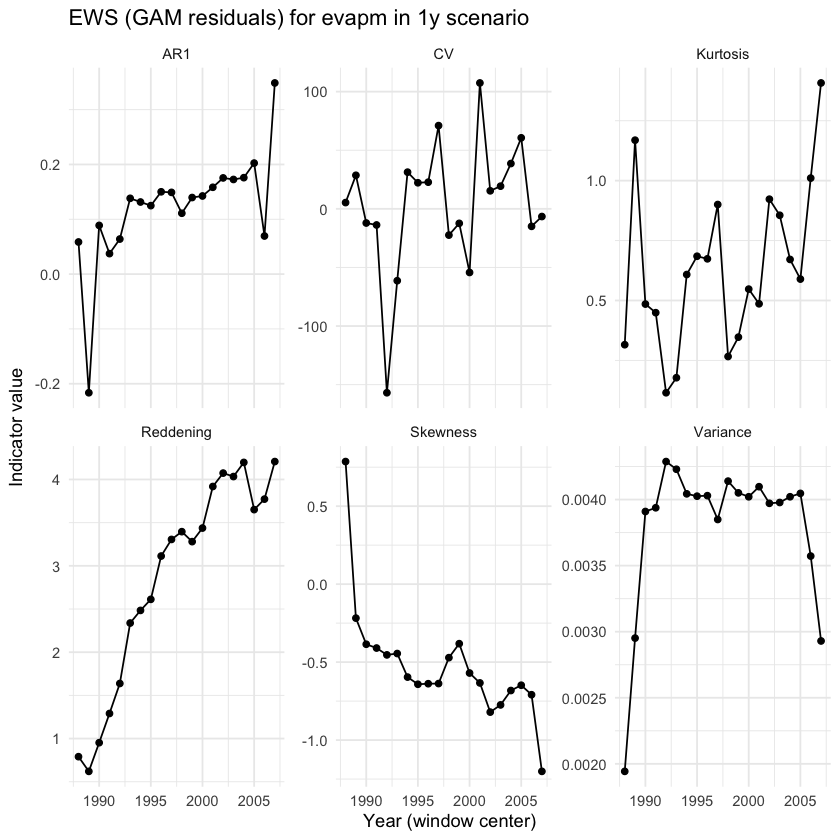

In [48]:
# Filter one Scenario × Variable
ews_one <- ews_gam_manual %>%
  filter(Scenario == "1y", Variable == "evapm") %>%
  select(time_center, AR1, Variance, CV, Skewness, Kurtosis, Reddening)

# Convert to long format for plotting
ews_one_long <- ews_one %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Line plot with facets for each indicator
ggplot(ews_one_long, aes(x = time_center, y = Value)) +
  geom_line() +
  geom_point() +
  facet_wrap(~ Indicator, scales = "free_y") +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Indicator value",
    title = "EWS (GAM residuals) for evapm in 1y scenario"
  )

Adding missing grouping variables: `Scenario`, `Variable`


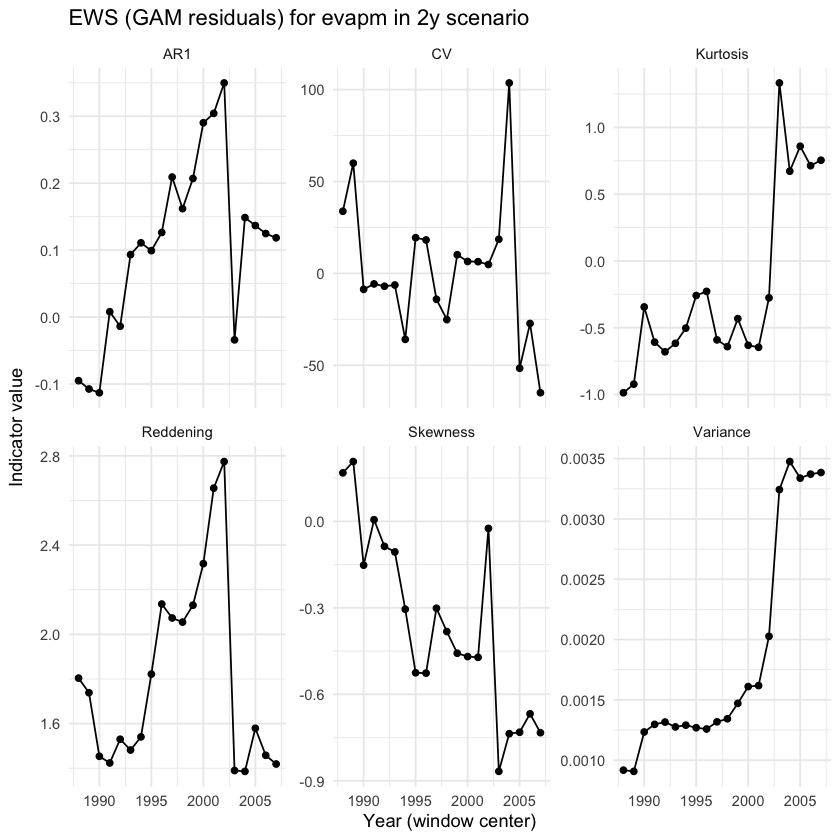

In [46]:
# Filter one Scenario × Variable
ews_one_allfreq <- ews_gam_manual_allfreq %>%
  filter(Scenario == "8y", Variable == "evapm") %>%
  select(time_center, AR1, Variance, CV, Skewness, Kurtosis, Reddening)

# Convert to long format for plotting
ews_one_long_allfreq <- ews_one_allfreq %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Line plot with facets for each indicator
ggplot(ews_one_long_allfreq, aes(x = time_center, y = Value)) +
  geom_line() +
  geom_point() +
  facet_wrap(~ Indicator, scales = "free_y") +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Indicator value",
    title = "EWS (GAM residuals) for evapm in 2y scenario"
  )

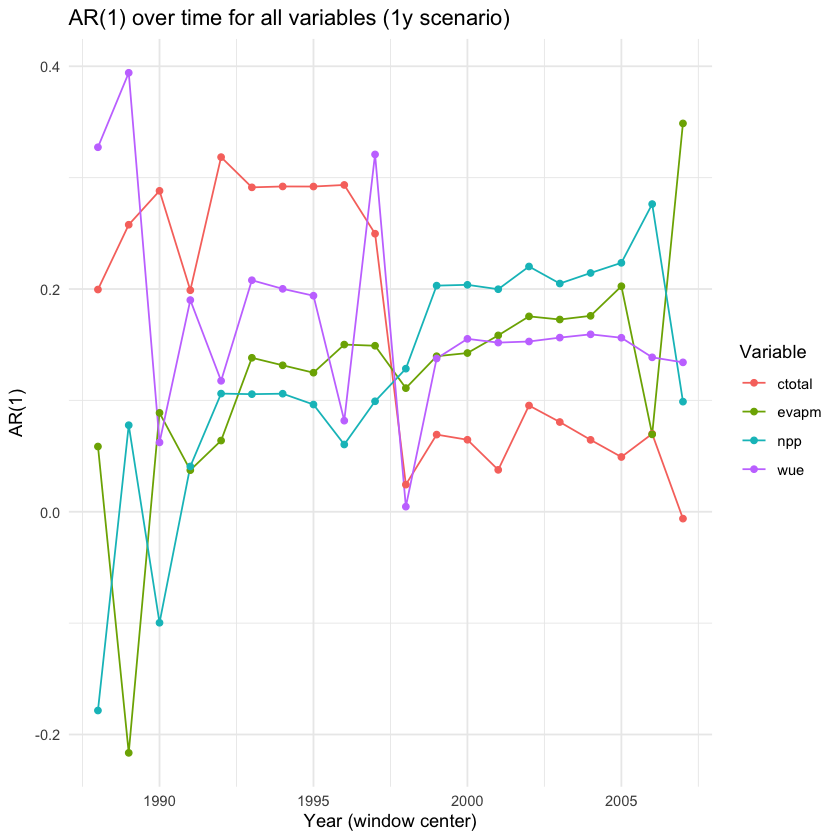

In [49]:
# Filter one scenario and keep only AR1
ews_ar1 <- ews_gam_manual %>%
  filter(Scenario == "1y") %>%
  select(Scenario, Variable, time_center, AR1)

ggplot(ews_ar1, aes(x = time_center, y = AR1, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "AR(1)",
    title = "AR(1) over time for all variables (1y scenario)"
  )


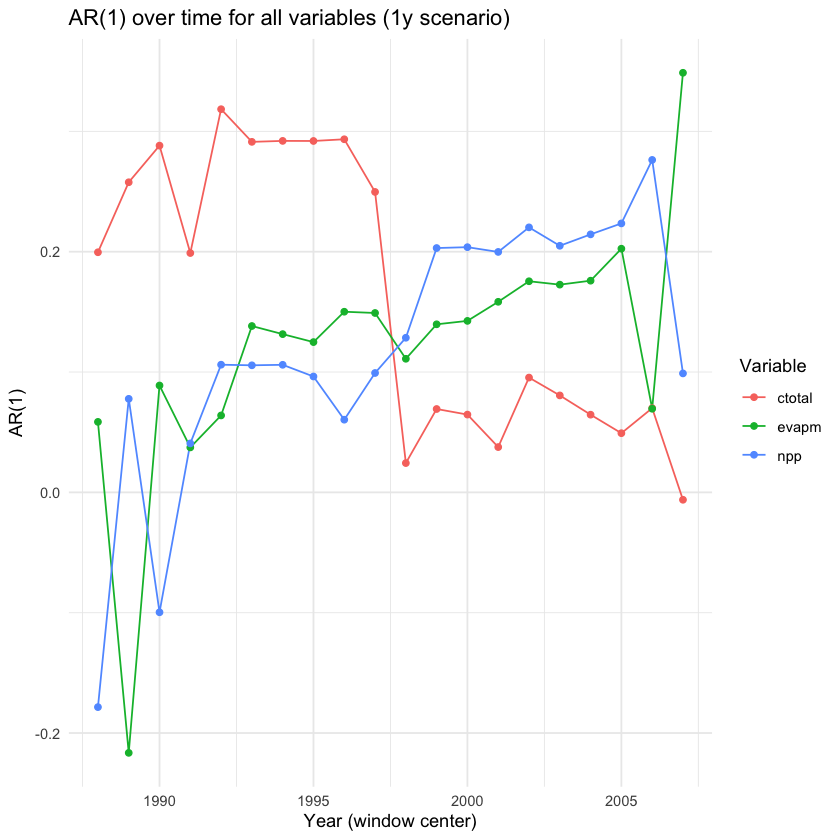

In [47]:
# Filter one scenario and keep only AR1
ews_ar1_allfreq <- ews_gam_manual_allfreq %>%
  filter(Scenario == "2y") %>%
  select(Scenario, Variable, time_center, AR1)

ggplot(ews_ar1_allfreq, aes(x = time_center, y = AR1, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "AR(1)",
    title = "AR(1) over time for all variables (2y scenario)"
  )


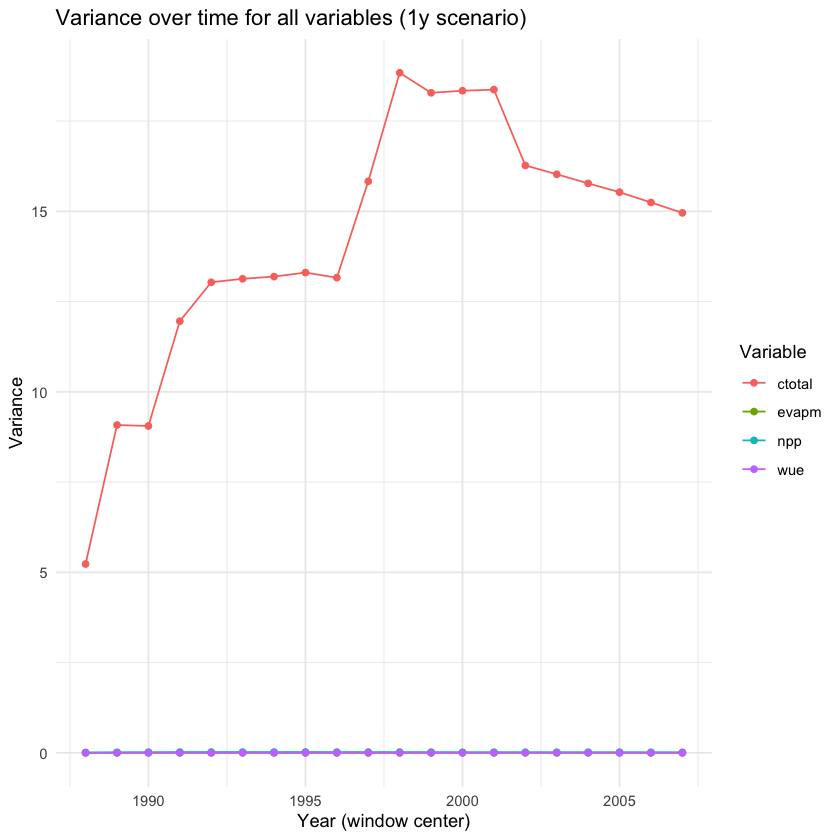

In [50]:
ews_var <- ews_gam_manual %>%
  filter(Scenario == "1y") %>%
  select(Scenario, Variable, time_center, Variance)

ggplot(ews_var, aes(x = time_center, y = Variance, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Variance",
    title = "Variance over time for all variables (1y scenario)"
  )


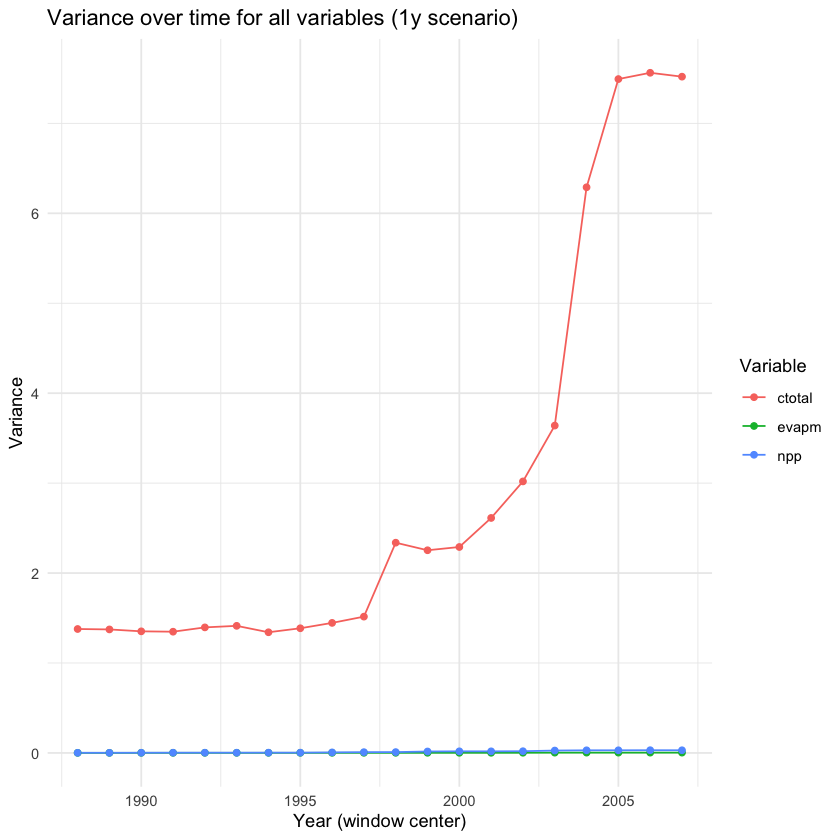

In [49]:
ews_var_allfreq <- ews_gam_manual_allfreq %>%
  filter(Scenario == "8y") %>%
  select(Scenario, Variable, time_center, Variance)

ggplot(ews_var_allfreq, aes(x = time_center, y = Variance, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Variance",
    title = "Variance over time for all variables (1y scenario)"
  )


In [51]:
ews_long_gam <- ews_gam_manual %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam <- ews_long_gam %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )


In [52]:
# annual_detrended must already exist and contain:
# Year, Scenario, Variable, Value, residuals

annual_detrended_std <- annual_detrended %>%
  group_by(Scenario, Variable) %>%
  mutate(
    # Standardised residuals: mean = 0, sd = 1 within each Scenario × Variable
    residuals_std = as.numeric(scale(residuals))
  ) %>%
  ungroup()


In [53]:
compute_ews_window_std <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (standardised residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance (on standardised residuals)
    var_x <- var(xw, na.rm = TRUE)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [54]:
library(purrr)

ews_gam_std <- annual_detrended_std %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window_std(
        x    = .x$residuals_std,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [56]:
library(tidyr)
library(Kendall)

ews_long_std <- ews_gam_std %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_std <- ews_long_std %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_std)


# A tibble: 60 x 5
   Scenario Variable Indicator     tau           p
   <chr>    <chr>    <chr>       <dbl>       <dbl>
 1 1y       ctotal   AR1       -0.463  0.00476    
 2 1y       ctotal   Kurtosis  -0.274  0.0980     
 3 1y       ctotal   Reddening -0.505  0.00205    
 4 1y       ctotal   Skewness   0.737  0.00000644 
 5 1y       ctotal   Variance   0.484  0.00315    
 6 1y       evapm    AR1        0.663  0.0000501  
 7 1y       evapm    Kurtosis   0.358  0.0297     
 8 1y       evapm    Reddening  0.874  0.000000119
 9 1y       evapm    Skewness  -0.663  0.0000500  
10 1y       evapm    Variance  -0.0105 0.974      
# i 50 more rows


In [58]:
find_onset <- function(time, value, k = 3, frac_baseline = 0.3) {
  n <- length(value)
  if (n == 0 || all(is.na(value))) return(NA_real_)
  
  baseline_n <- max(5, floor(frac_baseline * n))
  base_vals  <- value[1:baseline_n]
  thr <- median(base_vals, na.rm = TRUE) + sd(base_vals, na.rm = TRUE)
  
  above <- value > thr
  
  run_len <- 0
  onset_time <- NA_real_
  
  for (i in seq_along(above)) {
    if (isTRUE(above[i])) {
      run_len <- run_len + 1
      if (run_len >= k) {
        onset_time <- time[i]
        break
      }
    } else {
      run_len <- 0
    }
  }
  
  onset_time
}

core_indicators <- c("AR1", "Variance")

onset_std <- ews_long_std %>%
  filter(Indicator %in% core_indicators) %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    onset_time = find_onset(time_center, Value),
    .groups    = "drop"
  )

variable_level_onset_std <- onset_std %>%
  group_by(Scenario, Variable) %>%
  summarise(
    earliest_onset = min(onset_time, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Scenario, earliest_onset)

print(variable_level_onset_std)


Warning message:
"There was 1 warning in `summarise()`.
i In argument: `earliest_onset = min(onset_time, na.rm = TRUE)`.
i In group 2: `Scenario = "1y"` and `Variable = "evapm"`.
Caused by warning in `min()`:
! nenhum argumento n~ao faltante para min; retornando Inf"


# A tibble: 12 x 3
   Scenario Variable earliest_onset
   <chr>    <chr>             <dbl>
 1 1y       wue                1998
 2 1y       ctotal             1999
 3 1y       npp                2001
 4 1y       evapm               Inf
 5 7y       evapm              1995
 6 7y       npp                1995
 7 7y       ctotal             1998
 8 7y       wue                2005
 9 regclim  ctotal             1995
10 regclim  evapm              1998
11 regclim  npp                2002
12 regclim  wue                2003


In [60]:
print(variable_level_onset_std %>% filter(Scenario == "1y"))


# A tibble: 4 x 3
  Scenario Variable earliest_onset
  <chr>    <chr>             <dbl>
1 1y       wue                1998
2 1y       ctotal             1999
3 1y       npp                2001
4 1y       evapm               Inf


In [61]:
library(dplyr)
library(tidyr)
library(Kendall)

# EWS table using standardised residuals (from previous steps)
# ews_gam_std has: Scenario, Variable, time_center, AR1, Variance, Skewness, Kurtosis, Reddening

ews_evap_1y <- ews_gam_std %>%
  filter(Scenario == "1y", Variable == "evapm")

# Look at Kendall trends for each indicator
Kendall(ews_evap_1y$time_center, ews_evap_1y$AR1)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Variance)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Reddening)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Skewness)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Kurtosis)


tau = 0.663, 2-sided pvalue =5.0068e-05

tau = -0.0105, 2-sided pvalue =0.97412

tau = 0.874, 2-sided pvalue =1.1921e-07

tau = -0.663, 2-sided pvalue =5.002e-05

tau = 0.358, 2-sided pvalue =0.029723

In [62]:
find_onset_soft <- function(time, value,
                            frac_baseline = 0.4,
                            n_sigma       = 0.5,
                            k             = 2) {
  n <- length(value)
  if (n == 0 || all(is.na(value))) return(NA_real_)
  
  baseline_n <- max(5, floor(frac_baseline * n))
  
  base_vals <- value[1:baseline_n]
  thr <- median(base_vals, na.rm = TRUE) + n_sigma * sd(base_vals, na.rm = TRUE)
  
  above <- value > thr
  
  run_len <- 0
  onset_time <- NA_real_
  
  for (i in seq_along(above)) {
    if (isTRUE(above[i])) {
      run_len <- run_len + 1
      if (run_len >= k) {
        onset_time <- time[i]
        break
      }
    } else {
      run_len <- 0
    }
  }
  
  onset_time
}


In [64]:
# Long format for evapm–1y
ews_evap_1y_long <- ews_evap_1y %>%
  select(time_center, AR1, Variance, Reddening, Skewness, Kurtosis) %>%
  pivot_longer(
    cols = c(AR1, Variance, Reddening, Skewness, Kurtosis),
    names_to = "Indicator",
    values_to = "Value"
  )

# Onset per indicator using the softer rule
onset_evap_soft <- ews_evap_1y_long %>%
  group_by(Indicator) %>%
  summarise(
    onset_time = find_onset_soft(time_center, Value),
    .groups    = "drop"
  )

print(onset_evap_soft)



Adding missing grouping variables: `Scenario`, `Variable`


# A tibble: 5 x 2
  Indicator onset_time
  <chr>          <dbl>
1 AR1             1997
2 Kurtosis        1996
3 Reddening       1994
4 Skewness          NA
5 Variance          NA


In [66]:
earliest_evap_onset <- onset_evap_soft %>%
  filter(Indicator %in% c("AR1", "Variance", "Reddening")) %>%
  summarise(min_onset = min(onset_time, na.rm = TRUE))

print(earliest_evap_onset)

# A tibble: 1 x 1
  min_onset
      <dbl>
1      1994


In [68]:
# Long EWS table using standardised residuals
ews_long_std2 <- ews_gam_std %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Soft onset per Scenario × Variable × Indicator
onset_soft_all <- ews_long_std2 %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    onset_time = find_onset_soft(time_center, Value),
    .groups    = "drop"
  )

# Earliest onset per variable using core indicators
core_indicators <- c("AR1", "Variance", "Reddening")

variable_level_onset_soft <- onset_soft_all %>%
  filter(Indicator %in% core_indicators) %>%
  group_by(Scenario, Variable) %>%
  summarise(
    earliest_onset = {
      x <- onset_time
      if (all(is.na(x))) NA_real_ else min(x, na.rm = TRUE)
    },
    .groups = "drop"
  ) %>%
  arrange(Scenario, earliest_onset)

variable_level_onset_soft


# A tibble: 12 x 3
   Scenario Variable earliest_onset
   <chr>    <chr>             <dbl>
 1 1y       wue                1989
 2 1y       npp                1993
 3 1y       ctotal             1994
 4 1y       evapm              1994
 5 7y       ctotal             1989
 6 7y       evapm              1989
 7 7y       wue                1991
 8 7y       npp                1993
 9 regclim  evapm              1989
10 regclim  wue                1991
11 regclim  ctotal             1992
12 regclim  npp                1997


A.2.b. Using detrended from internal ews package

In [86]:
library(dplyr)
library(tidyr)

# annual_detrended already exists and contains: Year, Scenario, Variable, Value, residuals
annual_long <- annual_detrended %>%
  select(Year, Scenario, Variable, Value) %>%
  distinct()

print(annual_long %>%
  count(Scenario, Variable))


# A tibble: 12 x 3
   Scenario Variable     n
   <chr>    <chr>    <int>
 1 1y       ctotal      38
 2 1y       evapm       38
 3 1y       npp         38
 4 1y       wue         38
 5 7y       ctotal      38
 6 7y       evapm       38
 7 7y       npp         38
 8 7y       wue         38
 9 regclim  ctotal      38
10 regclim  evapm       38
11 regclim  npp         38
12 regclim  wue         38


In [87]:
library(earlywarnings)

run_ews_default_vec <- function(df, winsize = 50, detrending = "gaussian") {
  # df must contain: Year, Value
  
  # 1) Sort by time and remove missing values
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(Value))
  
  # 2) Skip if the cleaned series is too short
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Use only the value vector; time index will be implicit (1,2,3,...)
  ts_vec <- df_clean$Value
  
  ew <- tryCatch(
    generic_ews(
      timeseries    = ts_vec,      # numeric vector
      winsize       = winsize,     # percentage of series length
      detrending    = detrending,  # "gaussian" is standard
      logtransform  = FALSE,
      interpolate   = FALSE,
      AR_n          = FALSE,
      powerspectrum = FALSE
    ),
    error = function(e) {
      message("generic_ews error: ", conditionMessage(e))
      NULL
    }
  )
  
  if (is.null(ew)) return(NULL)
  
  ew_df <- as.data.frame(ew)
  
  # In vector mode, generic_ews usually returns a column 'tim' with window index
  if ("tim" %in% names(ew_df)) {
    ew_df <- ew_df %>% rename(time = tim)
  }
  
  ew_df
}


In [ ]:
library(purrr)

ews_default <- annual_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ {
    ew <- run_ews_default_vec(.x, winsize = 50, detrending = "gaussian")
    
    if (is.null(ew)) {
      tibble()
    } else {
      as_tibble(ew)
    }
  }) %>%
  ungroup()


In [91]:
library(earlywarnings)

# Example: evapm in 1y scenario
x_evap_1y <- annual_long %>%
  filter(Scenario == "1y", Variable == "evapm") %>%
  arrange(Year)



In [51]:
# =========================
# Sensitivity ranking of EWS metrics vs regclim (bootstrap on Kendall tau)
# =========================

library(dplyr)
library(tidyr)
library(purrr)

#---------------------------
# 1) Read the user's EWS table
#---------------------------

ews <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/analysis_2025/yearly_ecosystem_state/ews_gam_manual_allfreq.csv")

# Core early-warning metrics typically interpreted as resilience loss when increasing
core_metrics <- c("AR1", "Variance", "Reddening")

#---------------------------
# 2) Helper: compute Kendall tau for a metric vs time
#---------------------------

kendall_tau <- function(time, y) {
  # Compute Kendall rank correlation (tau) between time and the metric
  # This is a robust, non-parametric trend measure
  as.numeric(cor(time, y, method = "kendall", use = "complete.obs"))
}

#---------------------------
# 3) Helper: bootstrap Kendall tau (resampling paired (time, y))
#    Note: This assumes weak temporal autocorrelation in the metric series.
#    If your residual-based metrics show strong ACF, consider block bootstrap.
#---------------------------

bootstrap_tau <- function(time, y, B = 2000, seed = 1) {
  # Bootstrap distribution of Kendall tau by resampling indices with replacement
  set.seed(seed)
  n <- length(time)
  replicate(B, {
    idx <- sample.int(n, size = n, replace = TRUE)
    kendall_tau(time[idx], y[idx])
  })
}

#---------------------------
# 4) For each drought scenario, compare tau_scenario - tau_regclim using bootstrap
#---------------------------

compare_to_regclim <- function(df_var, scenario_name, metric_name, B = 2000, seed = 1) {
  # df_var must contain rows for regclim and the target scenario for one Variable
  # This function returns delta_tau, bootstrap CI, and a one-sided p-value for delta_tau > 0

  # Subset baseline and scenario
  base <- df_var %>% filter(Scenario == "regclim") %>% arrange(time_center)
  scen <- df_var %>% filter(Scenario == scenario_name) %>% arrange(time_center)

  # Align by common time_center (safety)
  common_time <- intersect(base$time_center, scen$time_center)
  base <- base %>% filter(time_center %in% common_time) %>% arrange(time_center)
  scen <- scen %>% filter(time_center %in% common_time) %>% arrange(time_center)

  time <- base$time_center
  y0 <- base[[metric_name]]
  y1 <- scen[[metric_name]]

  # Observed taus
  tau0 <- kendall_tau(time, y0)
  tau1 <- kendall_tau(time, y1)
  delta_obs <- tau1 - tau0

  # Bootstrap tau distributions
  tau0_bs <- bootstrap_tau(time, y0, B = B, seed = seed)
  tau1_bs <- bootstrap_tau(time, y1, B = B, seed = seed + 1)

  # Bootstrap distribution of delta
  delta_bs <- tau1_bs - tau0_bs

  # 95% CI for delta
  ci <- quantile(delta_bs, probs = c(0.025, 0.975), na.rm = TRUE)

  # One-sided p-value for H1: delta_tau > 0
  p_one <- mean(delta_bs <= 0, na.rm = TRUE)

  tibble(
    delta_tau = delta_obs,
    ci_low = as.numeric(ci[1]),
    ci_high = as.numeric(ci[2]),
    p_one = p_one
  )
}

#---------------------------
# 5) Run comparisons for all Variables, drought scenarios, and core metrics
#---------------------------

drought_scenarios <- c("2y", "4y", "6y", "8y")

results <- ews %>%
  filter(Variable %in% unique(Variable)) %>%
  group_by(Variable) %>%
  group_split() %>%
  map_dfr(function(df_var) {
    var_name <- unique(df_var$Variable)

    expand_grid(
      Variable = var_name,
      Scenario = drought_scenarios,
      Metric = core_metrics
    ) %>%
      mutate(
        out = pmap(
          list(Scenario, Metric),
          ~ compare_to_regclim(df_var, scenario_name = ..1, metric_name = ..2, B = 2000, seed = 10)
        )
      ) %>%
      unnest(out)
  })

#---------------------------
# 6) Build a sensitivity score:
#    Sum of positive delta_tau that are supported (CI_low > 0 and p_one < 0.05)
#---------------------------

scores <- results %>%
  mutate(
    supported = (ci_low > 0) & (p_one < 0.05),
    contrib = ifelse(supported, delta_tau, 0)
  ) %>%
  group_by(Scenario, Variable) %>%
  summarise(
    sensitivity_score = sum(contrib, na.rm = TRUE),
    n_supported = sum(supported, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Scenario, desc(sensitivity_score))

# Ranking within each scenario
ranking_by_scenario <- scores %>%
  group_by(Scenario) %>%
  arrange(desc(sensitivity_score), .by_group = TRUE) %>%
  mutate(rank = row_number()) %>%
  ungroup()

# Overall ranking across all drought scenarios
ranking_overall <- scores %>%
  group_by(Variable) %>%
  summarise(total_score = sum(sensitivity_score, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_score))

# Print outputs
print(ranking_by_scenario)
print(ranking_overall)


# A tibble: 12 x 5
   Scenario Variable sensitivity_score n_supported  rank
   <chr>    <chr>                <dbl>       <int> <int>
 1 2y       npp                  2.48            2     1
 2 2y       evapm                0.579           1     2
 3 2y       ctotal               0               0     3
 4 4y       npp                  1.84            2     1
 5 4y       evapm                0.916           1     2
 6 4y       ctotal               0.863           1     3
 7 6y       evapm                1.17            1     1
 8 6y       npp                  1.17            2     2
 9 6y       ctotal               0.926           1     3
10 8y       npp                  1.26            2     1
11 8y       evapm                1.08            1     2
12 8y       ctotal               0.747           1     3
# A tibble: 3 x 2
  Variable total_score
  <chr>          <dbl>
1 npp             6.76
2 evapm           3.75
3 ctotal          2.54


RECOVERY TIME ANALYSIS

In [112]:
# minimal checks
# Basic checks: make sure required columns exist
stopifnot(all(c("Scenario", "Variable", "Year", "Value") %in% names(allfreq_long)))

# Ensure Year is numeric and data are ordered
allfreq_long <- allfreq_long %>%
  mutate(Year = as.numeric(Year)) %>%
  arrange(Scenario, Variable, Year)

# Convert model calendar year to simulation year (if needed)
start_year_model <- min(allfreq_long$Year, na.rm = TRUE)

allfreq_long <- allfreq_long %>%
  mutate(
    sim_year = as.numeric(Year) - start_year_model + 1
  )


# Keep sim_year as the timeline variable (simulation year)
allfreq_long <- allfreq_long %>%
  mutate(
    sim_year = as.numeric(sim_year)
  ) %>%
  arrange(Scenario, Variable, sim_year)
print(head(allfreq_long))




# A tibble: 6 x 5
   Year Scenario Variable Value sim_year
  <dbl> <chr>    <chr>    <dbl>    <dbl>
1  1979 2y       ctotal    56.9        1
2  1980 2y       ctotal    58.3        2
3  1981 2y       ctotal    57.9        3
4  1982 2y       ctotal    59.1        4
5  1983 2y       ctotal    59.2        5
6  1984 2y       ctotal    58.0        6


In [113]:
library(dplyr)

# Rename calendar year to avoid accidental use inside functions
allfreq_long <- allfreq_long %>%
  rename(calendar_year = Year)


In [114]:
library(dplyr)
library(tidyr)
library(purrr)

# =========================
# 1) Read tagged precipitation file
# =========================
prec_tagged <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/Prec_data/prec_values_yearly_all_recurrence_LONG_tagged.csv")

# Check required columns
stopifnot(all(c("year", "scenario", "phase") %in% names(prec_tagged)))

# Ensure consistent types
prec_tagged <- prec_tagged %>%
  mutate(
    year = as.numeric(year),
    scenario = as.character(scenario),
    phase = as.character(phase)
  )

# =========================
# 2) Convert calendar year -> simulation year
# =========================
# Define the first year of the simulation timeline
# If all scenarios share the same calendar timeline, global min(year) is correct.
start_year <- min(prec_tagged$year, na.rm = TRUE)

prec_tagged <- prec_tagged %>%
  mutate(
    sim_year = year - start_year + 1
  )

# Optional sanity check
print(range(prec_tagged$sim_year, na.rm = TRUE))

# =========================
# 3) Harmonize scenario names (baseline -> regclim)
# =========================
prec_tagged <- prec_tagged %>%
  mutate(
    scenario = recode(scenario, "baseline" = "regclim")
  )

# =========================
# 4) Extract drought event years using simulation year
# =========================
drought_years_tbl <- prec_tagged %>%
  filter(phase == "drought") %>%
  group_by(scenario) %>%
  summarize(
    drought_years = list(sort(unique(sim_year))),
    n_events = n_distinct(sim_year),
    .groups = "drop"
  )

print(drought_years_tbl)

# Convert to named list: list("2y"=c(...), "4y"=c(...), ...)
drought_years_by_scenario <- drought_years_tbl %>%
  select(scenario, drought_years) %>%
  deframe()

# Ensure regclim has no drought events (safe default)
if (!("regclim" %in% names(drought_years_by_scenario))) {
  drought_years_by_scenario[["regclim"]] <- numeric(0)
}

print(drought_years_by_scenario)

# =========================
# 5) Build event windows (event_year -> end_year) in simulation years
#    end_year = year before next drought (or last sim year)
# =========================
build_event_windows <- function(sim_years_vec, last_sim_year) {
  sim_years_vec <- sort(unique(sim_years_vec))
  if (length(sim_years_vec) == 0) {
    return(tibble(event_year = numeric(0), end_year = numeric(0)))
  }

  next_year <- c(sim_years_vec[-1], NA)
  end_year <- ifelse(is.na(next_year), last_sim_year, next_year - 1)

  tibble(event_year = sim_years_vec, end_year = end_year)
}

last_sim_year <- max(prec_tagged$sim_year, na.rm = TRUE)

event_windows_tbl <- drought_years_tbl %>%
  mutate(windows = map(drought_years, ~ build_event_windows(.x, last_sim_year))) %>%
  select(scenario, windows) %>%
  unnest(windows)

print(event_windows_tbl)


[1]  1 38
# A tibble: 4 x 3
  scenario drought_years n_events
  <chr>    <list>           <int>
1 2y       <dbl [19]>          19
2 4y       <dbl [10]>          10
3 6y       <dbl [7]>            7
4 8y       <dbl [5]>            5
$`2y`
 [1]  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38

$`4y`
 [1]  2  6 10 14 18 22 26 30 34 38

$`6y`
[1]  2  8 14 20 26 32 38

$`8y`
[1]  2 10 18 26 34

$regclim
numeric(0)

# A tibble: 41 x 3
   scenario event_year end_year
   <chr>         <dbl>    <dbl>
 1 2y                2        3
 2 2y                4        5
 3 2y                6        7
 4 2y                8        9
 5 2y               10       11
 6 2y               12       13
 7 2y               14       15
 8 2y               16       17
 9 2y               18       19
10 2y               20       21
# i 31 more rows


In [115]:
# Optional: ensure scenario names match precipitation scenarios
print(sort(unique(allfreq_long$Scenario)))
print(sort(unique(prec_tagged$scenario)))

[1] "2y"      "4y"      "6y"      "8y"      "regclim"
[1] "2y"      "4y"      "6y"      "8y"      "regclim"


In [122]:
# Compute anomalies vs regclim (year-by-year baseline)
# ----------------------------

compute_anomaly_vs_regclim <- function(df_long) {
  # Builds percent anomalies relative to regclim at the same simulation year.
  reg <- df_long %>%
    filter(Scenario == "regclim") %>%
    select(Variable, sim_year, reg_value = Value)

  df_long %>%
    left_join(reg, by = c("Variable", "sim_year")) %>%
    mutate(
      anomaly_pct = 100 * (Value - reg_value) / reg_value
    )
}

df_anom <- compute_anomaly_vs_regclim(allfreq_long)

In [128]:
# ----------------------------
# 5) Event-level recovery metrics
# ----------------------------

recovery_time_one_event <- function(year, anomaly_pct, event_year, end_year,
                                    threshold_pct = -10, consecutive_years = 2,
                                    search_from_next_year = TRUE) {
  # Recovery is defined as:
  #   anomaly_pct >= threshold_pct for 'consecutive_years' consecutive years
  # within the interval [event_year, end_year].
  # Returns recovery time (years) or NA if not recovered (censored).

  ord <- order(year)
  year <- year[ord]
  anomaly_pct <- anomaly_pct[ord]

  # Restrict to the inter-event interval
  ok <- (year >= event_year) & (year <= end_year)
  year <- year[ok]
  anomaly_pct <- anomaly_pct[ok]

  if (length(year) < consecutive_years) return(NA_real_)

  # Start searching from the year after the event if desired
  start_year <- ifelse(search_from_next_year, event_year + 1, event_year)
  start_idx <- which(year >= start_year)[1]
  if (is.na(start_idx)) return(NA_real_)

  for (i in start_idx:(length(year) - consecutive_years + 1)) {
    j <- i + consecutive_years - 1
    if (all(anomaly_pct[i:j] >= threshold_pct, na.rm = TRUE)) {
      return(year[i] - event_year)
    }
  }

  NA_real_
}


In [133]:

event_metrics_one_event <- function(year, anomaly_pct, event_year, end_year) {
  # Computes:
  # - impact_min: minimum anomaly (most negative) within interval
  # - t_to_min: time (years) from event to minimum
  # - auc_deficit: cumulative deficit (sum of negative anomalies, as positive magnitude)
  # - end_anomaly: anomaly at end of interval (how far from recovery at the deadline)

  ord <- order(year)
  year <- year[ord]
  anomaly_pct <- anomaly_pct[ord]

  ok <- (year >= event_year) & (year <= end_year)
  year_i <- year[ok]
  anom_i <- anomaly_pct[ok]

  if (length(year_i) == 0) {
    return(tibble(impact_min = NA_real_, t_to_min = NA_real_,
                  auc_deficit = NA_real_, end_anomaly = NA_real_))
  }

  impact_min <- min(anom_i, na.rm = TRUE)
  year_min <- year_i[which.min(anom_i)]
  t_to_min <- year_min - event_year

  auc_deficit <- sum(pmax(-anom_i, 0), na.rm = TRUE)

  # Anomaly at the end of the interval (useful when recovery is censored)
  end_anomaly <- anom_i[which.max(year_i)]

  tibble(
    impact_min = impact_min,
    t_to_min = t_to_min,
    auc_deficit = auc_deficit,
    end_anomaly = end_anomaly
  )
}


In [149]:

THRESHOLD_PCT <- -10
CONSECUTIVE_YEARS <- 2
SEARCH_NEXT <- TRUE

rec_events <- df_anom %>%
  filter(Scenario != "regclim") %>%
  # 1. Join gera produto cartesiano (todas as datas x todos os eventos do cenário)
  left_join(event_windows_tbl, by = c("Scenario" = "scenario"), relationship = "many-to-many") %>%
  
  # 2. FILTRO CRÍTICO: Manter apenas os anos relevantes para cada evento específico
  # Isso resolve o problema de duplicidade e garante que a função receba apenas os dados da janela
  filter(sim_year >= event_year & sim_year <= end_year + 10) %>% # +10 é uma margem de segurança
  
  group_by(Scenario, Variable, event_year, end_year) %>%
  group_modify(~ {
    # .y contém as chaves do grupo (event_year, end_year)
    ev_year <- .y$event_year
    en_year <- .y$end_year
    
    # Calcular Tempo de Recuperação
    rt <- recovery_time_one_event(
      year = .x$sim_year,
      anomaly_pct = .x$anomaly_pct,
      event_year = ev_year,
      end_year = en_year,
      threshold_pct = THRESHOLD_PCT,
      consecutive_years = CONSECUTIVE_YEARS,
      search_from_next_year = SEARCH_NEXT
    )
    
    # Calcular Métricas do Evento
    met <- event_metrics_one_event( # Certifique-se que essa função foi definida anteriormente!
      year = .x$sim_year,
      anomaly_pct = .x$anomaly_pct,
      event_year = ev_year,
      end_year = en_year
    )
    
    # Retornar tibble combinado
    tibble(
      rec_time = rt,
      censored = is.na(rt)
    ) %>% bind_cols(met)
  }) %>%
  ungroup()

# Verificação final
print(head(rec_events))

rec_summary <- rec_events


write.csv(rec_summary, "/Users/biancarius/Desktop/recovery_summary_allfreq.csv", row.names = FALSE)	

# A tibble: 6 x 10
  Scenario Variable event_year end_year rec_time censored impact_min t_to_min
  <chr>    <chr>         <dbl>    <dbl>    <dbl> <lgl>         <dbl>    <dbl>
1 2y       ctotal            2        3        1 FALSE         0.828        1
2 2y       ctotal            4        5        1 FALSE         2.46         1
3 2y       ctotal            6        7        1 FALSE         1.96         0
4 2y       ctotal            8        9        1 FALSE         0.565        0
5 2y       ctotal           10       11        1 FALSE         0.386        0
6 2y       ctotal           12       13       NA TRUE        -19.3          1
# i 2 more variables: auc_deficit <dbl>, end_anomaly <dbl>


**MAIN GOAL**

To identify which ecosystem process (ET, WUE, NPP, Carbon) shows the earliest and most robust signs of loss of resilience under increased drought frequency in the Amazon.


| Bloco                                                             | Objetivo principal                                                                 | Perguntas que responde                                                                                         | Métodos / análises                                                                                                                                                                                                                                                                                                           | Principais outputs                                                                                                                                                                                                                                                                                                                                                                                           |
| ----------------------------------------------------------------- | ---------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | ------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------ |
| **A – Early-warning signals (EWS)**                               | Detectar **perda de resiliência antes das quebras**                                | Existe perda de resiliência nas séries? Qual variável começa a perder resiliência primeiro?                    | - Detrending (GAM + STL/LOESS)<br> - Cálculo em janelas móveis de: **AR(1)**, **variância**, **coeficiente de variação (CV)**, **skewness**, **kurtosis**, **spectral reddening**<br> - Testes de tendência (Kendall τ, Sen slope) para cada EWS                                                                             | - Séries temporais de todos os EWS (por variável e cenário)<br> - Tabela com τ, p-value e **ano de início** do aumento de cada EWS<br> - **Ranking de variáveis** que dão sinal mais cedo (por cenário)                                                                                                                                                                                                      |
| **B – Breakpoints clássicos (sua análise original, fortalecida)** | Identificar **momentos de mudança estrutural** nas séries                          | Quando o sistema muda de regime em termos de média/tendência? As variáveis mudam no mesmo momento?             | - Métodos de **detecção de breakpoints em séries univariadas** (p.ex. `strucchange`, PELT, regressão segmentada simples)<br> - Aplicar o mesmo método a todas as variáveis e cenários<br> - Comparar posição dos breakpoints entre variáveis                                                                                 | - Ano(s) de breakpoint por variável e cenário<br> - Intervalos de confiança / incerteza desses anos (se disponível)<br> - Comparação direta: qual variável “quebra” primeiro em termos estruturais                                                                                                                                                                                                           |
| **C – Converging evidence em mudanças de tendência**              | Ver se os padrões de mudança são robustos a **múltiplos métodos**, incluindo o seu | As datas de mudança dependem do método? Tendência e sazonalidade contam a mesma história?                      | - **BFAST** (quebras em tendência + sazonalidade; se tiver dados mensais)<br> - **STL + trend filtering** na componente de tendência<br> - **Modelos state-space / Kalman** (local level / local linear trend) para tendências contínuas<br> - Comparar esses métodos com os **breakpoints clássicos do Bloco B**            | - Anos de breakpoints por BFAST<br> - Anos de mudanças de inclinação da tendência (trend filtering)<br> - Séries de tendência suavizada (state-space) e possíveis mudanças de regime<br> - Comparação entre métodos, mostrando se os breakpoints clássicos são robustos                                                                                                                                      |
| **D – Causalidade temporal (VAR / Granger / VAR-LASSO)**          | Entender **ordem temporal e influência entre processos**                           | ET/WUE antecipam NPP e Carbono? Quem dirige a dinâmica do sistema?                                             | - Construção de matrizes multivariadas (ET, WUE, NPP, Carbon) por cenário<br> - Modelos **VAR(p)** com seleção de ordem via AIC/BIC<br> - **Granger causality** para todos os pares X → Y<br> - **VAR-LASSO** para checar robustez da estrutura causal                                                                       | - Matriz de p-values de Granger (quem causa quem)<br> - Grafo causal (setas ET → NPP, etc.) por cenário<br> - Medidas de “out-degree” (quantas variáveis cada uma influencia)<br> - Comparação com ranking de EWS (A) e com o timing dos breakpoints (B–C)                                                                                                                                                   |
| **E – Critical transition timing & síntese avançada**             | Estimar **timing das transições com incerteza** e integrar todas as evidências     | Quando a transição ocorre (com IC)? Quando ela teria sido detectada “online”? O que tudo isso diz em conjunto? | - **Bayesian change point detection** (ex.: `bcp`, `mcp`) para cada série<br> - **Piecewise regression** com breakpoint(s) + incerteza (IC / bootstrap)<br> - **SPRT / CUSUM** para detecção “online” do primeiro desvio<br> - Integração com EWS (A), breakpoints clássicos (B), métodos de tendência (C) e causalidade (D) | - Breakpoints Bayesianos com **intervalos de credibilidade**<br> - Breakpoints frequentistas (piecewise) com IC<br> - Ano em que SPRT/CUSUM detecta mudança para cada variável (detecção “online”)<br> - **Linha do tempo integrada** por variável: início de EWS → detecção online → breakpoints (clássicos e bayesianos)<br> - Conclusão final sobre **quais processos são leading indicators** de colapso |


**A) EARLY WARNING SIGNALS**

*A.1 - Organizing data*


In [ ]:
library(dplyr)
library(tidyr)
library(mgcv)
library(ggplot2)


Anexando pacote: 'dplyr'


Os seguintes objetos s~ao mascarados por 'package:stats':

    filter, lag


Os seguintes objetos s~ao mascarados por 'package:base':

    intersect, setdiff, setequal, union


Carregando pacotes exigidos: nlme


Anexando pacote: 'nlme'


O seguinte objeto 'e mascarado por 'package:dplyr':

    collapse


This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

Warning message:
"pacote 'ggplot2' foi compilado no R vers~ao 4.4.3"


In [ ]:
annual_data <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/yearly_mean_tables/yearly_grouped.csv")

annual_long <- annual_data %>%
  rename(
    Year     = date,
    Scenario = frequency
  ) %>%
  select(Year, Scenario, npp, ctotal, evapm, wue) %>%
  # Drop years where all key variables are NA (post-collapse years)
  filter(!(is.na(npp) & is.na(ctotal) & is.na(evapm) & is.na(wue))) %>%
  pivot_longer(
    cols      = c(npp, ctotal, evapm, wue),
    names_to  = "Variable",
    values_to = "Value"
  )


In [ ]:
# doing the same for all the frequencies

yr_allfreq <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/analysis_2025/yearly_ecosystem_state/combined_yearly_vars.csv")

allfreq_long <- yr_allfreq %>%
  rename(
    Year     = date,
    Scenario = frequency
  ) %>%
  select(Year, Scenario, npp, ctotal, evapm) %>%
  # Drop years where all key variables are NA (post-collapse years)
  filter(!(is.na(npp) & is.na(ctotal) & is.na(evapm))) %>%
  pivot_longer(
    cols      = c(npp, ctotal, evapm),
    names_to  = "Variable",
    values_to = "Value"
  )

In [ ]:
print(unique(annual_long$Scenario))

ERROR: Error: objeto 'annual_long' n~ao encontrado


In [ ]:
print(unique(allfreq_long$Scenario))

[1] "2y"      "4y"      "6y"      "8y"      "regclim"


Detrending time series with GAM

In [ ]:
#This code removes long-term temporal trends from annual model outputs using Generalized Additive Models (GAMs).
#For each combination of Scenario and Variable, a GAM is fitted with Year as a smooth predictor and the variable 
#value as the response. The smooth term captures the low-frequency (long-term) trend over time. 
#The residuals from this model represent the interannual variability after detrending and are stored as a new 
#column (residuals) in the dataset. The detrending is applied independently to each scenario–variable pair to 
#avoid mixing trends across different model configurations or output variables.

detrend_with_gam <- function(df) {
  # df must have Year and Value
  fit <- gam(Value ~ s(Year, k = 10), data = df)
  df$residuals <- residuals(fit)
  df
}

annual_detrended <- annual_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ detrend_with_gam(.x)) %>%
  ungroup()

In [ ]:
# same with all freq
detrend_with_gam <- function(df) {
  # df must have Year and Value
  fit <- gam(Value ~ s(Year, k = 10), data = df)
  df$residuals <- residuals(fit)
  df
}

annual_detrended_allfreq <- allfreq_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ detrend_with_gam(.x)) %>%
  ungroup()

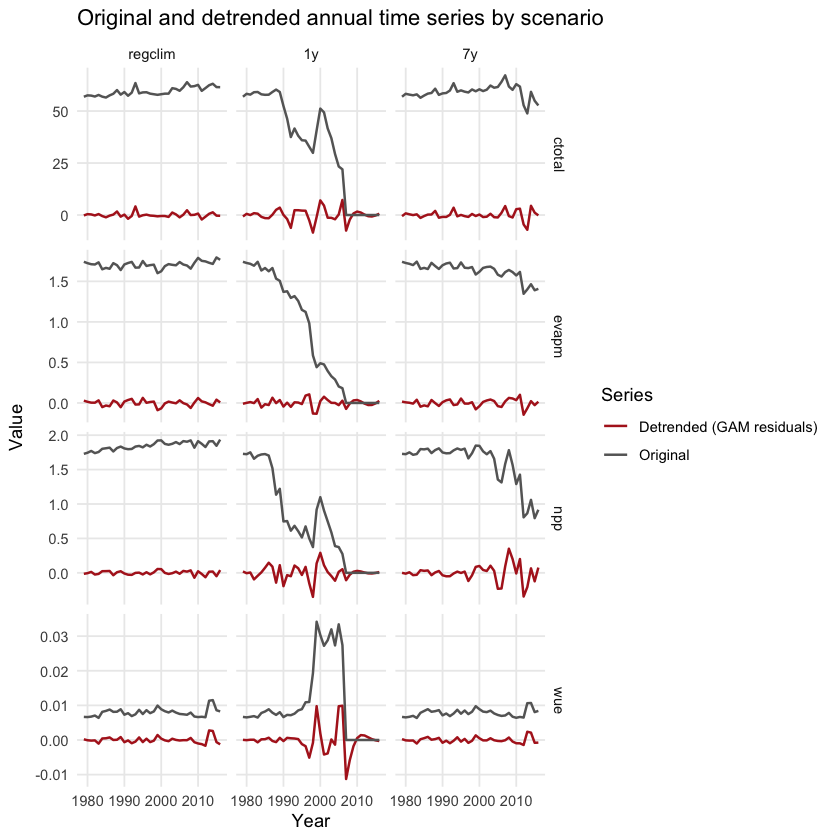

In [ ]:
library(dplyr)
library(tidyr)
library(ggplot2)

# Choose the scenarios you want to compare
scenarios_to_plot <- c("regclim", "1y", "7y")

annual_detrended %>%
  filter(Scenario %in% scenarios_to_plot) %>%
  # Put original and detrended values in long format for nicer plotting + legend
  pivot_longer(
    cols = c(Value, residuals),
    names_to = "Series",
    values_to = "TS_value"
  ) %>%
  mutate(
    # Nice labels for legend
    Series = recode(Series,
                    Value = "Original",
                    residuals = "Detrended (GAM residuals)"),
    # Optional: order scenarios in a meaningful way
    Scenario = factor(Scenario, levels = scenarios_to_plot)
  ) %>%
  ggplot(aes(x = Year, y = TS_value, color = Series)) +
  geom_line(linewidth = 0.7) +
  facet_grid(Variable ~ Scenario, scales = "free_y") +
  labs(
    x = "Year",
    y = "Value",
    title = "Original and detrended annual time series by scenario",
    color = "Series"
  ) +
  scale_color_manual(
    values = c("Original" = "grey40",
               "Detrended (GAM residuals)" = "firebrick")
  ) +
  theme_minimal() +
  theme(
    strip.background = element_blank(),
    panel.grid.minor = element_blank()
  )


Interpretation of detrended annual time series

The detrending procedure based on Generalized Additive Models (GAMs) successfully isolates the low-frequency temporal component of the annual time series. For all variables and scenarios, the residuals are centered around zero and preserve the interannual variability, indicating that the GAM smooth captures the long-term trend while removing systematic temporal structure from the residuals.

Clear differences emerge among the climate scenarios. The regclim and 7y scenarios exhibit relatively smooth long-term trajectories, with moderate interannual variability and comparable residual magnitudes across variables. In these scenarios, the detrended series can be interpreted as stationary interannual anomalies, suggesting that the system remains dynamically stable over most of the simulation period.

In contrast, the 1y scenario displays pronounced non-stationary behavior. All variables show abrupt declines and strong departures from their previous trajectories, consistent with a regime shift or systemic collapse in the modeled ecosystem. In this case, the GAM smooth is unable to fully capture the abrupt transition, resulting in substantially larger residual amplitudes. Consequently, the detrended series in the 1y scenario reflects not only interannual variability but also signals associated with structural instability of the system.

The comparison between scenarios suggests that increased climate forcing first manifests as enhanced variability (as observed in the 7y scenario) before leading to an abrupt loss of system stability under the most extreme forcing (1y). The marked increase in residual variance preceding and during the transition in the 1y scenario is consistent with theoretical expectations of resilience loss and may be interpreted as an early-warning signal of impending regime change.

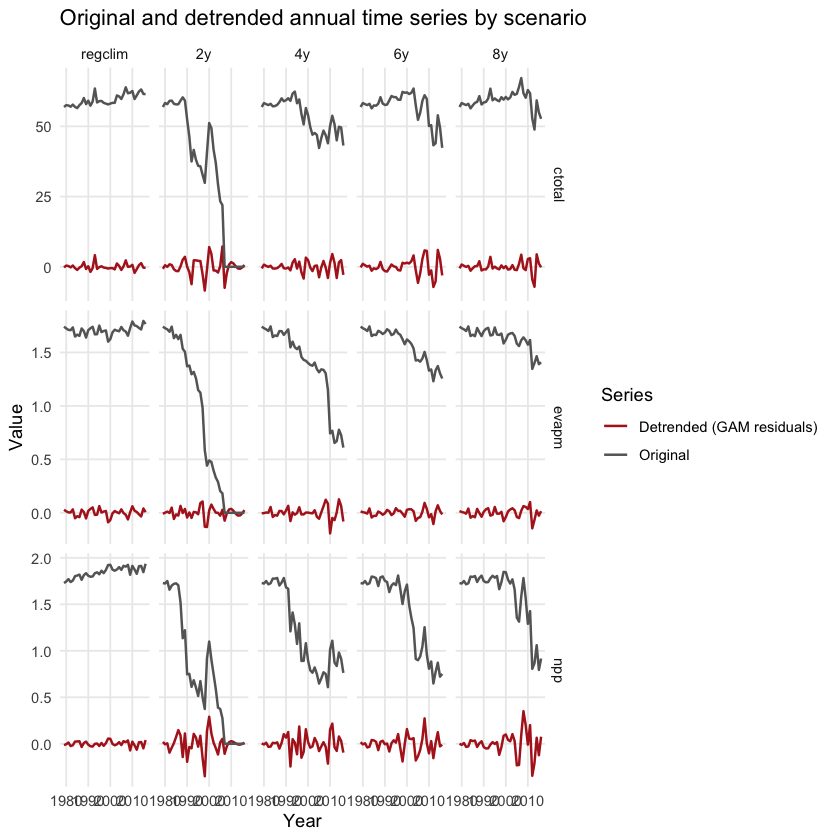

In [ ]:
#doing the same for all freq

library(dplyr)
library(tidyr)
library(ggplot2)

# Choose the scenarios you want to compare
scenarios_to_plot <- c("regclim", "2y", "4y", "6y", "8y")

annual_detrended_allfreq %>%
  filter(Scenario %in% scenarios_to_plot) %>%
  # Put original and detrended values in long format for nicer plotting + legend
  pivot_longer(
    cols = c(Value, residuals),
    names_to = "Series",
    values_to = "TS_value"
  ) %>%
  mutate(
    # Nice labels for legend
    Series = recode(Series,
                    Value = "Original",
                    residuals = "Detrended (GAM residuals)"),
    # Optional: order scenarios in a meaningful way
    Scenario = factor(Scenario, levels = scenarios_to_plot)
  ) %>%
  ggplot(aes(x = Year, y = TS_value, color = Series)) +
  geom_line(linewidth = 0.7) +
  facet_grid(Variable ~ Scenario, scales = "free_y") +
  labs(
    x = "Year",
    y = "Value",
    title = "Original and detrended annual time series by scenario",
    color = "Series"
  ) +
  scale_color_manual(
    values = c("Original" = "grey40",
               "Detrended (GAM residuals)" = "firebrick")
  ) +
  theme_minimal() +
  theme(
    strip.background = element_blank(),
    panel.grid.minor = element_blank()
  )


No seu gráfico, **cinza = série original** (nível absoluto + tendência de longo prazo) e **vermelho = resíduos do GAM** (a parte “rápida”: variação interanual depois de remover a tendência suave).

### 1) O que o vermelho “significa” exatamente

Para cada *Scenario × Variable*, o GAM estima uma curva suave ( \hat{f}(Year) ) que captura a **mudança de baixa frequência** (o “drift” de décadas, colapsos graduais, mudanças estruturais lentas).
O que você plota em vermelho é:

[
residual_t = Value_t - \hat{f}(Year_t)
]

Então:

* **Vermelho ~ 0** → aquele ano está *bem explicado* pela tendência suave.
* **Vermelho positivo** → ano “melhor que o esperado” dado o nível/trajetória de longo prazo.
* **Vermelho negativo** → ano “pior que o esperado” dado o nível/trajetória de longo prazo.
* **A amplitude do vermelho** → quanta **variabilidade interanual** sobra *independente do drift*.

> Importante: o resíduo está na **mesma unidade** do “Value”, mas agora centrado perto de zero.

---

### 2) Como ler cada painel (o jeito mais seguro)

Como você usou `scales = "free_y"`, **não compare a altura do cinza entre variáveis diferentes** (ctotal vs npp etc). Compare assim:

1. **Dentro de um mesmo painel (mesma variável + cenário)**

   * O cinza te diz **o comportamento de longo prazo** (estável? declinando? colapso?).
   * O vermelho te diz **a “nervosidade” anual** em torno disso (ruído pequeno vs grandes desvios).

2. **Entre cenários, na mesma variável (mesma linha)**

   * Compare **forma do cinza** (quando começa a queda, quão abrupta, se chega perto de zero).
   * Compare **variância do vermelho** (aumenta perto da transição? aparecem “spikes”? fica mais assimétrico?).

---

### 3) O que seu gráfico está mostrando (padrões visíveis)

**Regclim (coluna 1):**

* Cinza relativamente estável em ctotal/evapm/npp (sem queda forte).
* Vermelho pequeno e bem centrado em 0 → variabilidade interanual “normal”, sem grandes choques.

**2y (coluna 2):**

* Cinza em ctotal/evapm/npp cai de forma muito forte até ~zero (colapso/forte degradação).
* Vermelho fica grande principalmente **durante a transição** (período em que o sistema está mudando rápido).
* Depois que o cinza “gruda” perto de zero, o vermelho tende a ficar pequeno (porque não há mais dinâmica anual para variar: a tendência já “comeu” quase tudo).

**4y, 6y, 8y (colunas 3–5):**

* O cinza geralmente mostra **quedas mais tardias e/ou menos abruptas** do que em 2y.
* O vermelho costuma mostrar **picos** e aumento de variabilidade perto dos momentos em que o cinza muda de patamar (indicando anos anômalos “em cima” de uma tendência de degradação).

**wue (última linha):**

* Em 2y (e um pouco em 4y) há um **pico grande no cinza** (um evento/episódio marcante).
* No vermelho, isso aparece como um desvio muito forte (spike), porque aquele(s) ano(s) ficaram muito acima/abaixo do que a tendência suave esperaria.

---

### 4) A interpretação “ecológica/estatística” que esse detrending te permite

Depois do GAM, você consegue separar duas coisas:

* **Mudança de estado / tendência lenta (cinza)**: perda de biomassa/carbono, redução persistente de evapm/npp etc.
* **Variabilidade interanual (vermelho)**: resposta a “anos específicos” (clima extremo, sequência de eventos, ruído interno do modelo).

Isso é útil porque, por exemplo, se você quer métricas de “resiliência” baseadas em:

* variância,
* autocorrelação,
* assimetria,
* “spikes”,

você geralmente quer medir isso **na série detrended**, para não confundir “tendência de colapso” com “aumento de variabilidade”.

---

### 5) Dois alertas importantes (para sua base estatística ficar sólida)

1. **Se existe colapso forte**, o GAM pode estar usando parte do “sinal de transição” como tendência.

   * Resultado: o vermelho pode parecer “calmo” depois do colapso (o que é esperado), mas também pode **subestimar** mudanças rápidas se o smooth capturar demais.
   * Para análises de *early warning*, muitas vezes faz sentido detrendar **apenas no período pré-transição** (ou trabalhar com janelas móveis).

2. O seu `k = 10` impõe um grau de flexibilidade fixo.

   * Se `k` for pequeno demais, sobra tendência no resíduo (vermelho com drift).
   * Se `k` for grande demais, você começa a “comer” variabilidade interanual e deixar o vermelho artificialmente pequeno.
     *(Aqui o seu vermelho parece bem centrado, mas o caso 2y com quebra forte sempre merece checagem.)*

Se você quiser, eu te digo exatamente o que checar (diagnóstico do GAM, escolha de `k`, e se faz sentido usar correlação temporal tipo AR(1) nos resíduos), mas **só com esse gráfico** a leitura principal é:

* **2y** induz uma mudança de estado muito mais forte (cinza colapsa) e concentra grandes anomalias (vermelho) durante a transição;
* **regclim** é estável e tem variabilidade anual pequena;
* **4y–8y** ficam no meio termo, com quedas e “spikes” mais tardios/menos extremos, dependendo da variável.



Family: gaussian 
Link function: identity 

Formula:
Value ~ s(Year, k = 10)

Parametric coefficients:
            Estimate Std. Error t value Pr(>|t|)    
(Intercept)  33.9080     0.5789   58.58   <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

Approximate significance of smooth terms:
          edf Ref.df     F p-value    
s(Year) 8.312  8.869 170.4  <2e-16 ***
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

R-sq.(adj) =  0.976   Deviance explained = 98.1%
-REML = 115.36  Scale est. = 12.734    n = 38


Method: REML   Optimizer: outer newton
full convergence after 5 iterations.
Gradient range [-3.658849e-07,2.556628e-07]
(score 115.3586 & scale 12.73388).
Hessian positive definite, eigenvalue range [2.454984,18.85978].
Model rank =  10 / 10 

Basis dimension (k) checking results. Low p-value (k-index<1) may
indicate that k is too low, especially if edf is close to k'.

          k'  edf k-index p-value
s(Year) 9.00 8.31    0.91    0.22


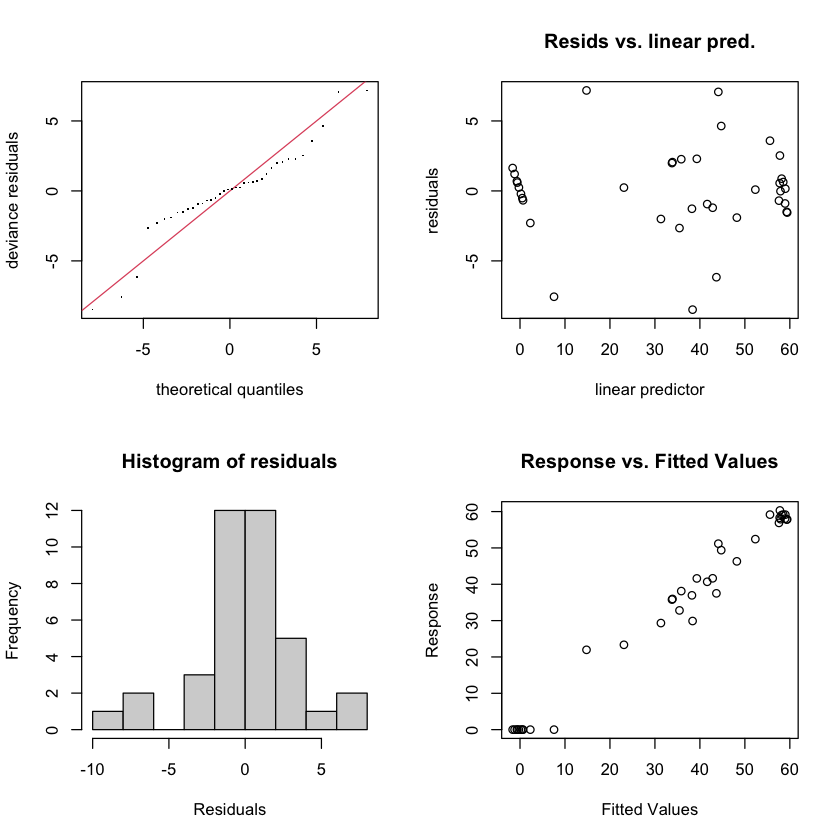

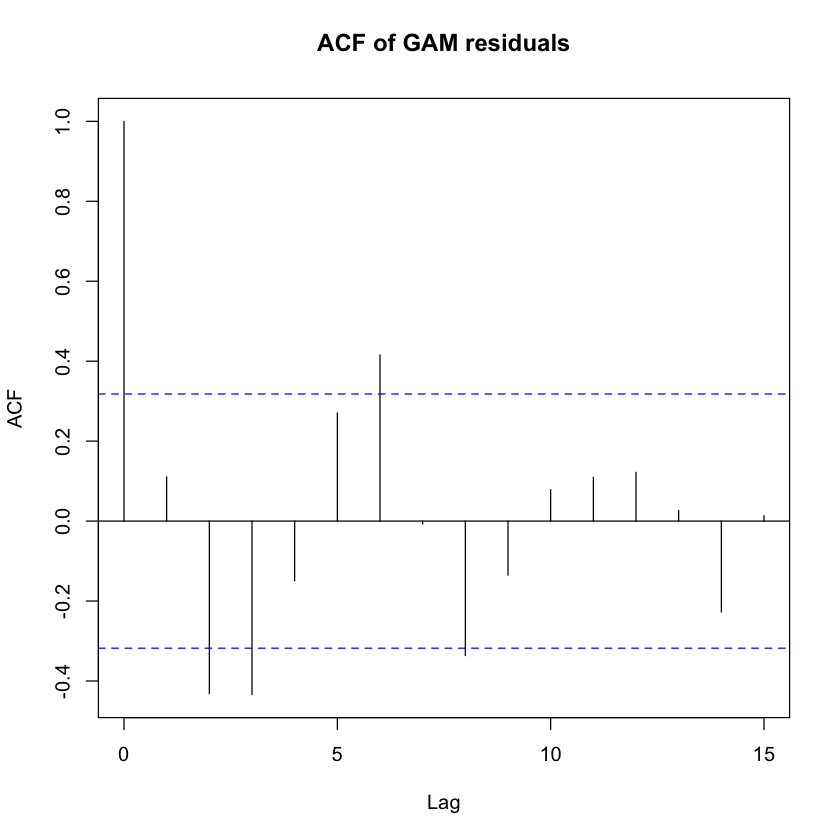

In [ ]:
library(mgcv)
library(dplyr)

# Example: one scenario and one variable
df_test <- annual_detrended_allfreq %>%
  filter(Scenario == "2y", Variable == "ctotal")

fit <- gam(Value ~ s(Year, k = 10),
           data = df_test,
           method = "REML")

summary(fit)
gam.check(fit)
acf(residuals(fit), main = "ACF of GAM residuals")




*A.2 - Calculating EWS*


In [ ]:
library(dplyr)
library(tidyr)
library(purrr)
library(mgcv)
library(earlywarnings)
library(Kendall)


Carregando pacotes exigidos: moments

Carregando pacotes exigidos: tgp

Carregando pacotes exigidos: tseries

Registered S3 method overwritten by 'quantmod':
  method            from
  as.zoo.data.frame zoo 


earlywarnings Copyright (C) 2011-2022 Vasilis Dakos and Leo Lahti
http://www.early-warning-signals.org




First, we will use the residuals from the detrended TS from GAM. After, we will use the detrending from the R package earlywarnings. We will compare the differences

A.2.a. Using detrended from GAM	

In [ ]:
library(e1071)  # for skewness and kurtosis
library(stats)


Anexando pacote: 'e1071'


Os seguintes objetos s~ao mascarados por 'package:moments':

    kurtosis, moment, skewness


O seguinte objeto 'e mascarado por 'package:ggplot2':

    element




In [ ]:

compute_ews_window <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance
    var_x <- var(xw, na.rm = TRUE)
    
    # Coefficient of variation
    mean_x <- mean(xw, na.rm = TRUE)
    cv_x <- ifelse(abs(mean_x) < .Machine$double.eps, NA, sqrt(var_x) / mean_x)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      CV          = cv_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [ ]:
#the same for all freq

compute_ews_window <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance
    var_x <- var(xw, na.rm = TRUE)
    
    # Coefficient of variation
    mean_x <- mean(xw, na.rm = TRUE)
    cv_x <- ifelse(abs(mean_x) < .Machine$double.eps, NA, sqrt(var_x) / mean_x)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      CV          = cv_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [ ]:

ews_gam_manual <- annual_detrended %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window(
        x    = .x$residuals,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [ ]:

ews_gam_manual_allfreq <- annual_detrended_allfreq %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window(
        x    = .x$residuals,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [ ]:
print(dim(ews_gam_manual_allfreq))
print(head(ews_gam_manual_allfreq))
print(names(ews_gam_manual_allfreq))

write.csv(ews_gam_manual_allfreq, "/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/analysis_2025/yearly_ecosystem_state/ews_gam_manual_allfreq.csv", row.names = FALSE)

[1] 300   9
# A tibble: 6 x 9
# Groups:   Scenario, Variable [1]
  Scenario Variable time_center   AR1 Variance      CV Skewness Kurtosis
  <chr>    <chr>          <dbl> <dbl>    <dbl>   <dbl>    <dbl>    <dbl>
1 2y       ctotal          1988 0.200     5.23   24.2    -0.989    1.78 
2 2y       ctotal          1989 0.258     9.08   -9.61   -1.39     2.13 
3 2y       ctotal          1990 0.288     9.05   -7.66   -1.31     1.99 
4 2y       ctotal          1991 0.199    12.0  -153.     -0.612    1.49 
5 2y       ctotal          1992 0.318    13.0    21.2    -0.592    1.02 
6 2y       ctotal          1993 0.291    13.1    53.0    -0.495    0.879
# i 1 more variable: Reddening <dbl>
[1] "Scenario"    "Variable"    "time_center" "AR1"         "Variance"   
[6] "CV"          "Skewness"    "Kurtosis"    "Reddening"  


In [ ]:
run_ews_gam <- function(df, winsize = 50) {
  # df must contain: Year, residuals
  
  # 1) Sort by time and remove NA residuals (e.g., post-collapse gaps)
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(residuals))
  
  # 2) If the cleaned series is too short, skip this group
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Build the time series matrix: first column = time, second = values
  ts_mat <- cbind(df_clean$Year, df_clean$residuals)
  
  # 4) Safely run generic_ews on GAM residuals
  ew <- tryCatch(
    suppressWarnings(
      generic_ews(
        timeseries    = ts_mat,
        winsize       = winsize,    # % of the available (pre-collapse) series
        detrending    = "no",       # GAM already removed the trend
        logtransform  = FALSE,
        interpolate   = FALSE,
        AR_n          = TRUE,
        powerspectrum = TRUE
      )
    ),
    error = function(e) NULL
  )
  
  if (is.null(ew)) return(NULL)
  
  as.data.frame(ew)
}


In [ ]:
run_ews_gam <- function(df, winsize = 50) {
  # df must contain: Year, residuals
  
  # 1) Sort by time and remove NA residuals (e.g., post-collapse gaps)
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(residuals))
  
  # 2) If the cleaned series is too short, skip this group
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Build the time series matrix: first column = time, second = values
  ts_mat <- cbind(df_clean$Year, df_clean$residuals)
  
  # 4) Safely run generic_ews on GAM residuals
  ew <- tryCatch(
    suppressWarnings(
      generic_ews(
        timeseries    = ts_mat,
        winsize       = winsize,    # % of the available (pre-collapse) series
        detrending    = "no",       # GAM already removed the trend
        logtransform  = FALSE,
        interpolate   = FALSE,
        AR_n          = TRUE,
        powerspectrum = TRUE
      )
    ),
    error = function(e) NULL
  )
  
  if (is.null(ew)) return(NULL)
  
  as.data.frame(ew)
}


In [ ]:
print(dim(ews_gam_manual))
print(head(ews_gam_manual))
print(names(ews_gam_manual))


[1] 240   9
# A tibble: 6 x 9
# Groups:   Scenario, Variable [1]
  Scenario Variable time_center   AR1 Variance      CV Skewness Kurtosis
  <chr>    <chr>          <dbl> <dbl>    <dbl>   <dbl>    <dbl>    <dbl>
1 1y       ctotal          1988 0.200     5.23   24.2    -0.989    1.78 
2 1y       ctotal          1989 0.258     9.08   -9.61   -1.39     2.13 
3 1y       ctotal          1990 0.288     9.05   -7.66   -1.31     1.99 
4 1y       ctotal          1991 0.199    12.0  -153.     -0.612    1.49 
5 1y       ctotal          1992 0.318    13.0    21.2    -0.592    1.02 
6 1y       ctotal          1993 0.291    13.1    53.0    -0.495    0.879
# i 1 more variable: Reddening <dbl>
[1] "Scenario"    "Variable"    "time_center" "AR1"         "Variance"   
[6] "CV"          "Skewness"    "Kurtosis"    "Reddening"  


In [ ]:
library(Kendall)
library(tidyr)

ews_long_gam <- ews_gam_manual %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam <- ews_long_gam %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_gam)


# A tibble: 72 x 5
   Scenario Variable Indicator    tau           p
   <chr>    <chr>    <chr>      <dbl>       <dbl>
 1 1y       ctotal   AR1       -0.463 0.00476    
 2 1y       ctotal   CV        -0.147 0.381      
 3 1y       ctotal   Kurtosis  -0.274 0.0980     
 4 1y       ctotal   Reddening -0.505 0.00205    
 5 1y       ctotal   Skewness   0.737 0.00000644 
 6 1y       ctotal   Variance   0.484 0.00315    
 7 1y       evapm    AR1        0.663 0.0000501  
 8 1y       evapm    CV         0.126 0.456      
 9 1y       evapm    Kurtosis   0.358 0.0297     
10 1y       evapm    Reddening  0.874 0.000000119
# i 62 more rows


In [ ]:
library(Kendall)
library(tidyr)

ews_long_gam_allfreq <- ews_gam_manual_allfreq %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam_allfreq <- ews_long_gam_allfreq %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_gam_allfreq)


# A tibble: 90 x 5
   Scenario Variable Indicator    tau           p
   <chr>    <chr>    <chr>      <dbl>       <dbl>
 1 2y       ctotal   AR1       -0.463 0.00476    
 2 2y       ctotal   CV        -0.147 0.381      
 3 2y       ctotal   Kurtosis  -0.274 0.0980     
 4 2y       ctotal   Reddening -0.505 0.00205    
 5 2y       ctotal   Skewness   0.737 0.00000644 
 6 2y       ctotal   Variance   0.484 0.00315    
 7 2y       evapm    AR1        0.663 0.0000501  
 8 2y       evapm    CV         0.126 0.456      
 9 2y       evapm    Kurtosis   0.358 0.0297     
10 2y       evapm    Reddening  0.874 0.000000119
# i 80 more rows


Adding missing grouping variables: `Scenario`, `Variable`


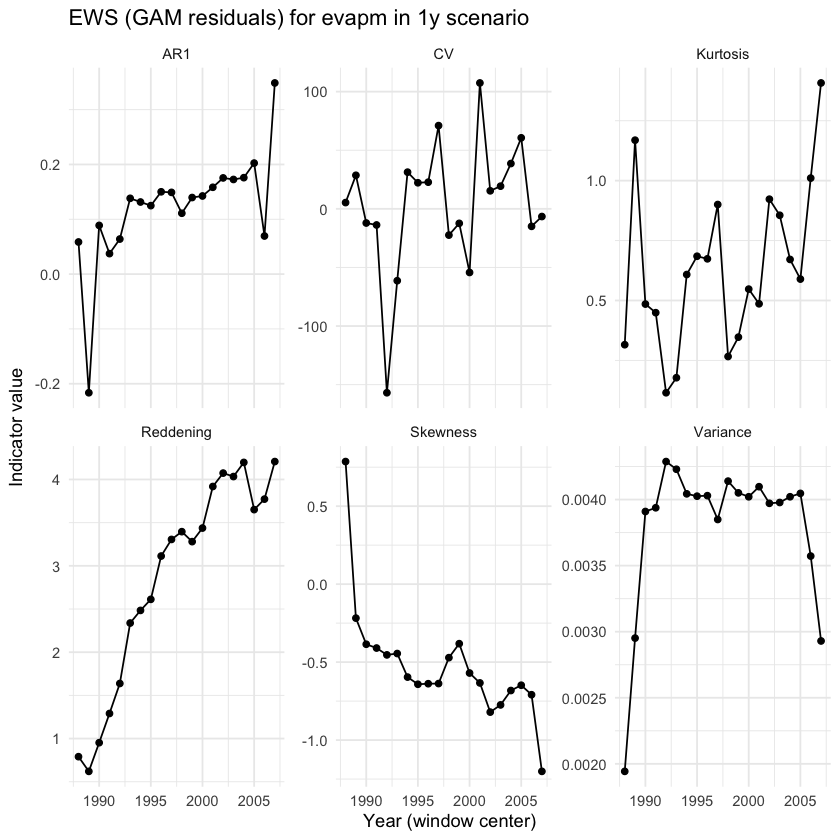

In [ ]:
# Filter one Scenario × Variable
ews_one <- ews_gam_manual %>%
  filter(Scenario == "1y", Variable == "evapm") %>%
  select(time_center, AR1, Variance, CV, Skewness, Kurtosis, Reddening)

# Convert to long format for plotting
ews_one_long <- ews_one %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Line plot with facets for each indicator
ggplot(ews_one_long, aes(x = time_center, y = Value)) +
  geom_line() +
  geom_point() +
  facet_wrap(~ Indicator, scales = "free_y") +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Indicator value",
    title = "EWS (GAM residuals) for evapm in 1y scenario"
  )

Adding missing grouping variables: `Scenario`, `Variable`


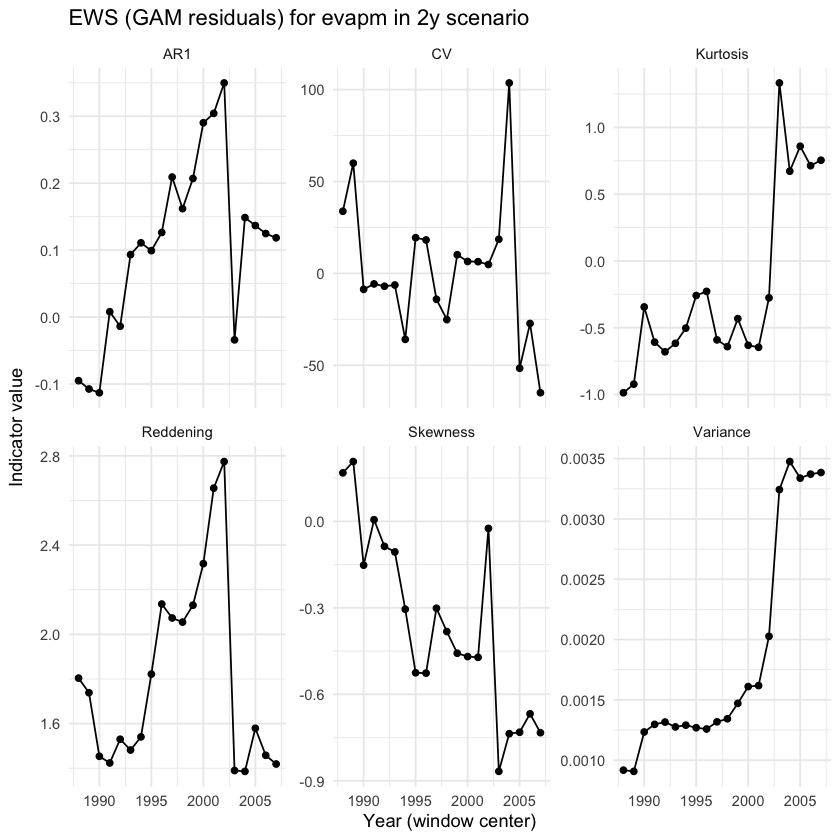

In [ ]:
# Filter one Scenario × Variable
ews_one_allfreq <- ews_gam_manual_allfreq %>%
  filter(Scenario == "8y", Variable == "evapm") %>%
  select(time_center, AR1, Variance, CV, Skewness, Kurtosis, Reddening)

# Convert to long format for plotting
ews_one_long_allfreq <- ews_one_allfreq %>%
  pivot_longer(
    cols = c(AR1, Variance, CV, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Line plot with facets for each indicator
ggplot(ews_one_long_allfreq, aes(x = time_center, y = Value)) +
  geom_line() +
  geom_point() +
  facet_wrap(~ Indicator, scales = "free_y") +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Indicator value",
    title = "EWS (GAM residuals) for evapm in 2y scenario"
  )

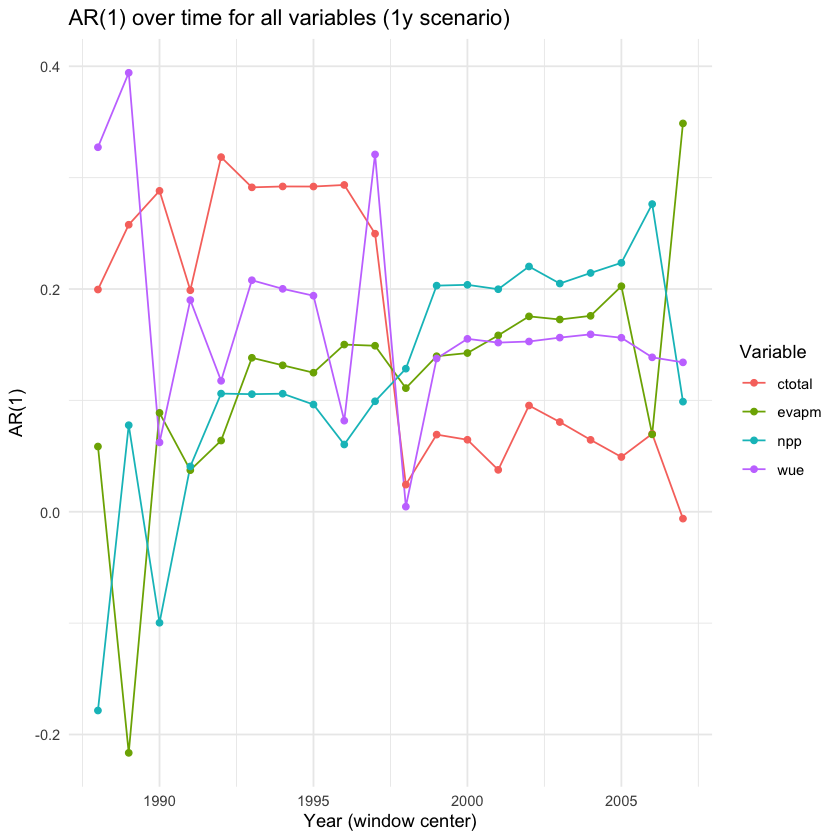

In [ ]:
# Filter one scenario and keep only AR1
ews_ar1 <- ews_gam_manual %>%
  filter(Scenario == "1y") %>%
  select(Scenario, Variable, time_center, AR1)

ggplot(ews_ar1, aes(x = time_center, y = AR1, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "AR(1)",
    title = "AR(1) over time for all variables (1y scenario)"
  )


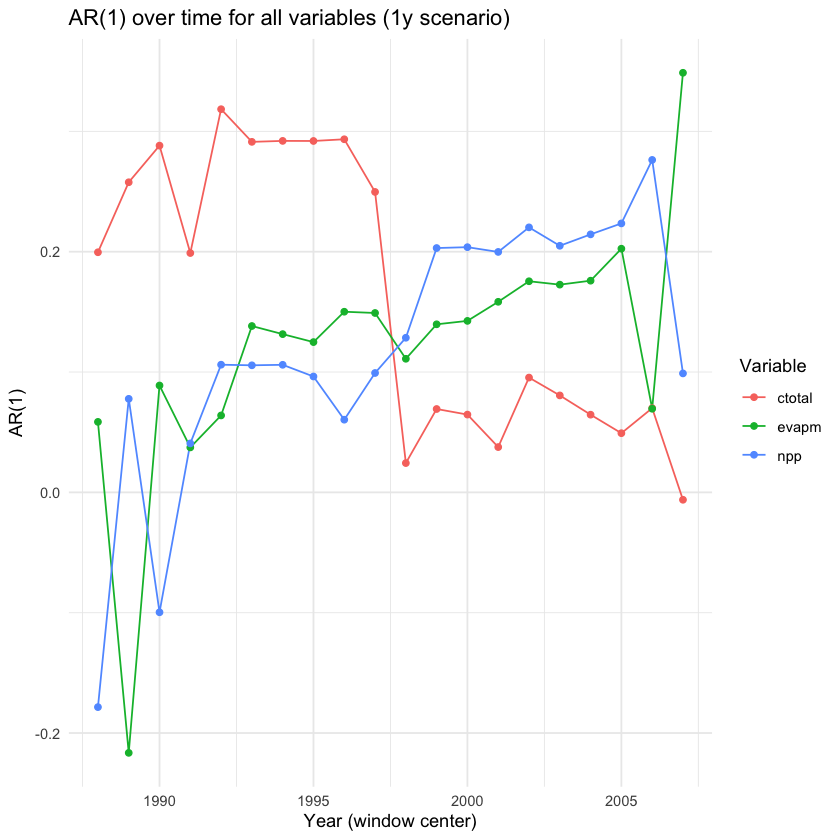

In [ ]:
# Filter one scenario and keep only AR1
ews_ar1_allfreq <- ews_gam_manual_allfreq %>%
  filter(Scenario == "2y") %>%
  select(Scenario, Variable, time_center, AR1)

ggplot(ews_ar1_allfreq, aes(x = time_center, y = AR1, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "AR(1)",
    title = "AR(1) over time for all variables (2y scenario)"
  )


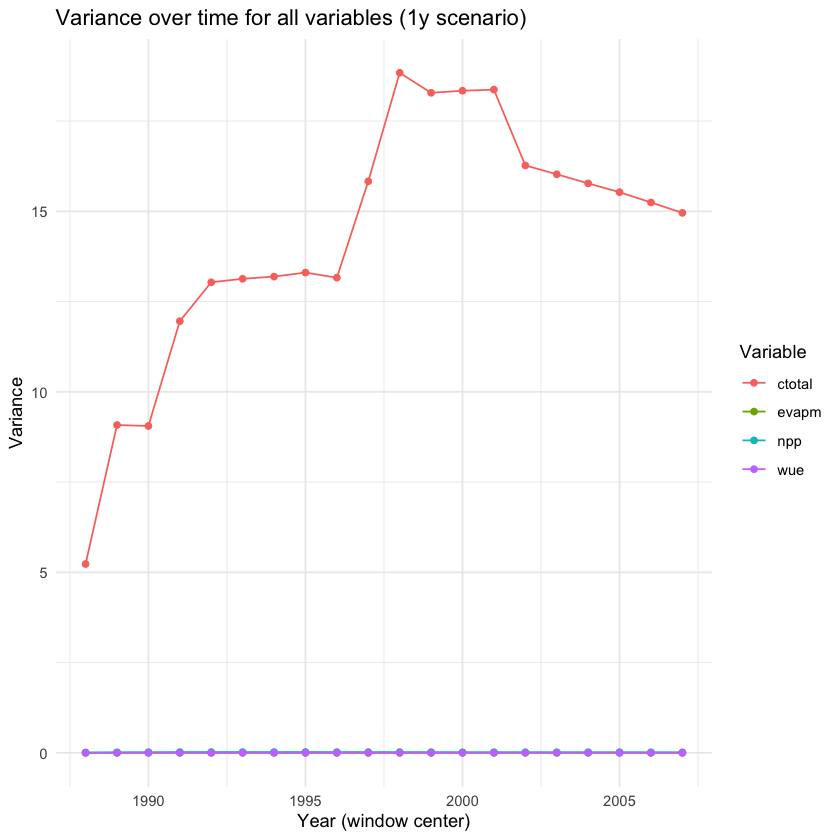

In [ ]:
ews_var <- ews_gam_manual %>%
  filter(Scenario == "1y") %>%
  select(Scenario, Variable, time_center, Variance)

ggplot(ews_var, aes(x = time_center, y = Variance, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Variance",
    title = "Variance over time for all variables (1y scenario)"
  )


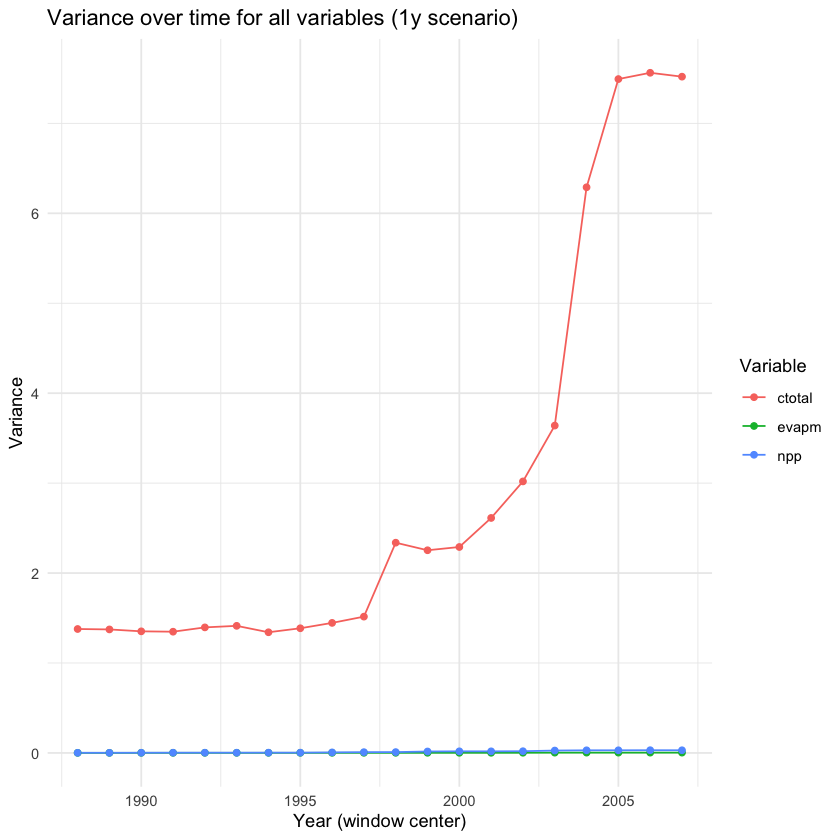

In [ ]:
ews_var_allfreq <- ews_gam_manual_allfreq %>%
  filter(Scenario == "8y") %>%
  select(Scenario, Variable, time_center, Variance)

ggplot(ews_var_allfreq, aes(x = time_center, y = Variance, color = Variable)) +
  geom_line() +
  geom_point() +
  theme_minimal() +
  labs(
    x = "Year (window center)",
    y = "Variance",
    title = "Variance over time for all variables (1y scenario)"
  )


In [ ]:
ews_long_gam <- ews_gam_manual %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_gam <- ews_long_gam %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )


In [ ]:
# annual_detrended must already exist and contain:
# Year, Scenario, Variable, Value, residuals

annual_detrended_std <- annual_detrended %>%
  group_by(Scenario, Variable) %>%
  mutate(
    # Standardised residuals: mean = 0, sd = 1 within each Scenario × Variable
    residuals_std = as.numeric(scale(residuals))
  ) %>%
  ungroup()


In [ ]:
compute_ews_window_std <- function(x, time, win_frac = 0.5) {
  # x: numeric vector (standardised residuals)
  # time: corresponding time (Year)
  # win_frac: fraction of the series length used as window size
  
  n <- length(x)
  win_size <- floor(win_frac * n)
  if (win_size < 5) {
    stop("Window too small for EWS.")
  }
  
  out_list <- list()
  idx <- 1
  
  for (start in 1:(n - win_size + 1)) {
    end <- start + win_size - 1
    xw <- x[start:end]
    tw <- time[start:end]
    
    # AR(1)
    acf_obj <- acf(xw, plot = FALSE, lag.max = 1, na.action = na.pass)
    ar1 <- acf_obj$acf[2]
    
    # Variance (on standardised residuals)
    var_x <- var(xw, na.rm = TRUE)
    
    # Skewness and kurtosis
    skew_x <- skewness(xw, na.rm = TRUE, type = 2)
    kurt_x <- kurtosis(xw, na.rm = TRUE, type = 2)
    
    # Spectral reddening: low vs. high frequency power
    spec_obj <- spec.pgram(xw, plot = FALSE)
    freq <- spec_obj$freq
    spec <- spec_obj$spec
    
    mid_freq   <- median(freq)
    low_power  <- sum(spec[freq <= mid_freq])
    high_power <- sum(spec[freq >  mid_freq])
    reddening  <- ifelse(high_power == 0, NA, low_power / high_power)
    
    # Center time of the window
    time_center <- mean(range(tw))
    
    out_list[[idx]] <- data.frame(
      time_center = time_center,
      AR1         = ar1,
      Variance    = var_x,
      Skewness    = skew_x,
      Kurtosis    = kurt_x,
      Reddening   = reddening
    )
    
    idx <- idx + 1
  }
  
  do.call(rbind, out_list)
}


In [ ]:
library(purrr)

ews_gam_std <- annual_detrended_std %>%
  group_by(Scenario, Variable) %>%
  nest() %>%
  mutate(
    ews = map(
      data,
      ~ compute_ews_window_std(
        x    = .x$residuals_std,
        time = .x$Year,
        win_frac = 0.5
      )
    )
  ) %>%
  select(-data) %>%
  unnest(ews)


In [ ]:
library(tidyr)
library(Kendall)

ews_long_std <- ews_gam_std %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

kendall_std <- ews_long_std %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    tau = Kendall(time_center, Value)$tau,
    p   = Kendall(time_center, Value)$sl[1],
    .groups = "drop"
  )

print(kendall_std)


# A tibble: 60 x 5
   Scenario Variable Indicator     tau           p
   <chr>    <chr>    <chr>       <dbl>       <dbl>
 1 1y       ctotal   AR1       -0.463  0.00476    
 2 1y       ctotal   Kurtosis  -0.274  0.0980     
 3 1y       ctotal   Reddening -0.505  0.00205    
 4 1y       ctotal   Skewness   0.737  0.00000644 
 5 1y       ctotal   Variance   0.484  0.00315    
 6 1y       evapm    AR1        0.663  0.0000501  
 7 1y       evapm    Kurtosis   0.358  0.0297     
 8 1y       evapm    Reddening  0.874  0.000000119
 9 1y       evapm    Skewness  -0.663  0.0000500  
10 1y       evapm    Variance  -0.0105 0.974      
# i 50 more rows


In [ ]:
find_onset <- function(time, value, k = 3, frac_baseline = 0.3) {
  n <- length(value)
  if (n == 0 || all(is.na(value))) return(NA_real_)
  
  baseline_n <- max(5, floor(frac_baseline * n))
  base_vals  <- value[1:baseline_n]
  thr <- median(base_vals, na.rm = TRUE) + sd(base_vals, na.rm = TRUE)
  
  above <- value > thr
  
  run_len <- 0
  onset_time <- NA_real_
  
  for (i in seq_along(above)) {
    if (isTRUE(above[i])) {
      run_len <- run_len + 1
      if (run_len >= k) {
        onset_time <- time[i]
        break
      }
    } else {
      run_len <- 0
    }
  }
  
  onset_time
}

core_indicators <- c("AR1", "Variance")

onset_std <- ews_long_std %>%
  filter(Indicator %in% core_indicators) %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    onset_time = find_onset(time_center, Value),
    .groups    = "drop"
  )

variable_level_onset_std <- onset_std %>%
  group_by(Scenario, Variable) %>%
  summarise(
    earliest_onset = min(onset_time, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Scenario, earliest_onset)

print(variable_level_onset_std)


Warning message:
"There was 1 warning in `summarise()`.
i In argument: `earliest_onset = min(onset_time, na.rm = TRUE)`.
i In group 2: `Scenario = "1y"` and `Variable = "evapm"`.
Caused by warning in `min()`:
! nenhum argumento n~ao faltante para min; retornando Inf"


# A tibble: 12 x 3
   Scenario Variable earliest_onset
   <chr>    <chr>             <dbl>
 1 1y       wue                1998
 2 1y       ctotal             1999
 3 1y       npp                2001
 4 1y       evapm               Inf
 5 7y       evapm              1995
 6 7y       npp                1995
 7 7y       ctotal             1998
 8 7y       wue                2005
 9 regclim  ctotal             1995
10 regclim  evapm              1998
11 regclim  npp                2002
12 regclim  wue                2003


In [ ]:
print(variable_level_onset_std %>% filter(Scenario == "1y"))


# A tibble: 4 x 3
  Scenario Variable earliest_onset
  <chr>    <chr>             <dbl>
1 1y       wue                1998
2 1y       ctotal             1999
3 1y       npp                2001
4 1y       evapm               Inf


In [ ]:
library(dplyr)
library(tidyr)
library(Kendall)

# EWS table using standardised residuals (from previous steps)
# ews_gam_std has: Scenario, Variable, time_center, AR1, Variance, Skewness, Kurtosis, Reddening

ews_evap_1y <- ews_gam_std %>%
  filter(Scenario == "1y", Variable == "evapm")

# Look at Kendall trends for each indicator
Kendall(ews_evap_1y$time_center, ews_evap_1y$AR1)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Variance)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Reddening)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Skewness)
Kendall(ews_evap_1y$time_center, ews_evap_1y$Kurtosis)


tau = 0.663, 2-sided pvalue =5.0068e-05

tau = -0.0105, 2-sided pvalue =0.97412

tau = 0.874, 2-sided pvalue =1.1921e-07

tau = -0.663, 2-sided pvalue =5.002e-05

tau = 0.358, 2-sided pvalue =0.029723

In [ ]:
find_onset_soft <- function(time, value,
                            frac_baseline = 0.4,
                            n_sigma       = 0.5,
                            k             = 2) {
  n <- length(value)
  if (n == 0 || all(is.na(value))) return(NA_real_)
  
  baseline_n <- max(5, floor(frac_baseline * n))
  
  base_vals <- value[1:baseline_n]
  thr <- median(base_vals, na.rm = TRUE) + n_sigma * sd(base_vals, na.rm = TRUE)
  
  above <- value > thr
  
  run_len <- 0
  onset_time <- NA_real_
  
  for (i in seq_along(above)) {
    if (isTRUE(above[i])) {
      run_len <- run_len + 1
      if (run_len >= k) {
        onset_time <- time[i]
        break
      }
    } else {
      run_len <- 0
    }
  }
  
  onset_time
}


In [ ]:
# Long format for evapm–1y
ews_evap_1y_long <- ews_evap_1y %>%
  select(time_center, AR1, Variance, Reddening, Skewness, Kurtosis) %>%
  pivot_longer(
    cols = c(AR1, Variance, Reddening, Skewness, Kurtosis),
    names_to = "Indicator",
    values_to = "Value"
  )

# Onset per indicator using the softer rule
onset_evap_soft <- ews_evap_1y_long %>%
  group_by(Indicator) %>%
  summarise(
    onset_time = find_onset_soft(time_center, Value),
    .groups    = "drop"
  )

print(onset_evap_soft)



Adding missing grouping variables: `Scenario`, `Variable`


# A tibble: 5 x 2
  Indicator onset_time
  <chr>          <dbl>
1 AR1             1997
2 Kurtosis        1996
3 Reddening       1994
4 Skewness          NA
5 Variance          NA


In [ ]:
earliest_evap_onset <- onset_evap_soft %>%
  filter(Indicator %in% c("AR1", "Variance", "Reddening")) %>%
  summarise(min_onset = min(onset_time, na.rm = TRUE))

print(earliest_evap_onset)

# A tibble: 1 x 1
  min_onset
      <dbl>
1      1994


In [ ]:
# Long EWS table using standardised residuals
ews_long_std2 <- ews_gam_std %>%
  pivot_longer(
    cols = c(AR1, Variance, Skewness, Kurtosis, Reddening),
    names_to = "Indicator",
    values_to = "Value"
  )

# Soft onset per Scenario × Variable × Indicator
onset_soft_all <- ews_long_std2 %>%
  group_by(Scenario, Variable, Indicator) %>%
  summarise(
    onset_time = find_onset_soft(time_center, Value),
    .groups    = "drop"
  )

# Earliest onset per variable using core indicators
core_indicators <- c("AR1", "Variance", "Reddening")

variable_level_onset_soft <- onset_soft_all %>%
  filter(Indicator %in% core_indicators) %>%
  group_by(Scenario, Variable) %>%
  summarise(
    earliest_onset = {
      x <- onset_time
      if (all(is.na(x))) NA_real_ else min(x, na.rm = TRUE)
    },
    .groups = "drop"
  ) %>%
  arrange(Scenario, earliest_onset)

variable_level_onset_soft


# A tibble: 12 x 3
   Scenario Variable earliest_onset
   <chr>    <chr>             <dbl>
 1 1y       wue                1989
 2 1y       npp                1993
 3 1y       ctotal             1994
 4 1y       evapm              1994
 5 7y       ctotal             1989
 6 7y       evapm              1989
 7 7y       wue                1991
 8 7y       npp                1993
 9 regclim  evapm              1989
10 regclim  wue                1991
11 regclim  ctotal             1992
12 regclim  npp                1997


A.2.b. Using detrended from internal ews package

In [ ]:
library(dplyr)
library(tidyr)

# annual_detrended already exists and contains: Year, Scenario, Variable, Value, residuals
annual_long <- annual_detrended %>%
  select(Year, Scenario, Variable, Value) %>%
  distinct()

print(annual_long %>%
  count(Scenario, Variable))


# A tibble: 12 x 3
   Scenario Variable     n
   <chr>    <chr>    <int>
 1 1y       ctotal      38
 2 1y       evapm       38
 3 1y       npp         38
 4 1y       wue         38
 5 7y       ctotal      38
 6 7y       evapm       38
 7 7y       npp         38
 8 7y       wue         38
 9 regclim  ctotal      38
10 regclim  evapm       38
11 regclim  npp         38
12 regclim  wue         38


In [ ]:
library(earlywarnings)

run_ews_default_vec <- function(df, winsize = 50, detrending = "gaussian") {
  # df must contain: Year, Value
  
  # 1) Sort by time and remove missing values
  df_clean <- df %>%
    arrange(Year) %>%
    filter(!is.na(Value))
  
  # 2) Skip if the cleaned series is too short
  if (nrow(df_clean) < 10) {
    return(NULL)
  }
  
  # 3) Use only the value vector; time index will be implicit (1,2,3,...)
  ts_vec <- df_clean$Value
  
  ew <- tryCatch(
    generic_ews(
      timeseries    = ts_vec,      # numeric vector
      winsize       = winsize,     # percentage of series length
      detrending    = detrending,  # "gaussian" is standard
      logtransform  = FALSE,
      interpolate   = FALSE,
      AR_n          = FALSE,
      powerspectrum = FALSE
    ),
    error = function(e) {
      message("generic_ews error: ", conditionMessage(e))
      NULL
    }
  )
  
  if (is.null(ew)) return(NULL)
  
  ew_df <- as.data.frame(ew)
  
  # In vector mode, generic_ews usually returns a column 'tim' with window index
  if ("tim" %in% names(ew_df)) {
    ew_df <- ew_df %>% rename(time = tim)
  }
  
  ew_df
}


In [ ]:
library(purrr)

ews_default <- annual_long %>%
  group_by(Scenario, Variable) %>%
  group_modify(~ {
    ew <- run_ews_default_vec(.x, winsize = 50, detrending = "gaussian")
    
    if (is.null(ew)) {
      tibble()
    } else {
      as_tibble(ew)
    }
  }) %>%
  ungroup()


In [ ]:
library(earlywarnings)

# Example: evapm in 1y scenario
x_evap_1y <- annual_long %>%
  filter(Scenario == "1y", Variable == "evapm") %>%
  arrange(Year)



In [ ]:
# =========================
# Sensitivity ranking of EWS metrics vs regclim (bootstrap on Kendall tau)
# =========================

library(dplyr)
library(tidyr)
library(purrr)

#---------------------------
# 1) Read the user's EWS table
#---------------------------

ews <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/analysis_2025/yearly_ecosystem_state/ews_gam_manual_allfreq.csv")

# Core early-warning metrics typically interpreted as resilience loss when increasing
core_metrics <- c("AR1", "Variance", "Reddening")

#---------------------------
# 2) Helper: compute Kendall tau for a metric vs time
#---------------------------

kendall_tau <- function(time, y) {
  # Compute Kendall rank correlation (tau) between time and the metric
  # This is a robust, non-parametric trend measure
  as.numeric(cor(time, y, method = "kendall", use = "complete.obs"))
}

#---------------------------
# 3) Helper: bootstrap Kendall tau (resampling paired (time, y))
#    Note: This assumes weak temporal autocorrelation in the metric series.
#    If your residual-based metrics show strong ACF, consider block bootstrap.
#---------------------------

bootstrap_tau <- function(time, y, B = 2000, seed = 1) {
  # Bootstrap distribution of Kendall tau by resampling indices with replacement
  set.seed(seed)
  n <- length(time)
  replicate(B, {
    idx <- sample.int(n, size = n, replace = TRUE)
    kendall_tau(time[idx], y[idx])
  })
}

#---------------------------
# 4) For each drought scenario, compare tau_scenario - tau_regclim using bootstrap
#---------------------------

compare_to_regclim <- function(df_var, scenario_name, metric_name, B = 2000, seed = 1) {
  # df_var must contain rows for regclim and the target scenario for one Variable
  # This function returns delta_tau, bootstrap CI, and a one-sided p-value for delta_tau > 0

  # Subset baseline and scenario
  base <- df_var %>% filter(Scenario == "regclim") %>% arrange(time_center)
  scen <- df_var %>% filter(Scenario == scenario_name) %>% arrange(time_center)

  # Align by common time_center (safety)
  common_time <- intersect(base$time_center, scen$time_center)
  base <- base %>% filter(time_center %in% common_time) %>% arrange(time_center)
  scen <- scen %>% filter(time_center %in% common_time) %>% arrange(time_center)

  time <- base$time_center
  y0 <- base[[metric_name]]
  y1 <- scen[[metric_name]]

  # Observed taus
  tau0 <- kendall_tau(time, y0)
  tau1 <- kendall_tau(time, y1)
  delta_obs <- tau1 - tau0

  # Bootstrap tau distributions
  tau0_bs <- bootstrap_tau(time, y0, B = B, seed = seed)
  tau1_bs <- bootstrap_tau(time, y1, B = B, seed = seed + 1)

  # Bootstrap distribution of delta
  delta_bs <- tau1_bs - tau0_bs

  # 95% CI for delta
  ci <- quantile(delta_bs, probs = c(0.025, 0.975), na.rm = TRUE)

  # One-sided p-value for H1: delta_tau > 0
  p_one <- mean(delta_bs <= 0, na.rm = TRUE)

  tibble(
    delta_tau = delta_obs,
    ci_low = as.numeric(ci[1]),
    ci_high = as.numeric(ci[2]),
    p_one = p_one
  )
}

#---------------------------
# 5) Run comparisons for all Variables, drought scenarios, and core metrics
#---------------------------

drought_scenarios <- c("2y", "4y", "6y", "8y")

results <- ews %>%
  filter(Variable %in% unique(Variable)) %>%
  group_by(Variable) %>%
  group_split() %>%
  map_dfr(function(df_var) {
    var_name <- unique(df_var$Variable)

    expand_grid(
      Variable = var_name,
      Scenario = drought_scenarios,
      Metric = core_metrics
    ) %>%
      mutate(
        out = pmap(
          list(Scenario, Metric),
          ~ compare_to_regclim(df_var, scenario_name = ..1, metric_name = ..2, B = 2000, seed = 10)
        )
      ) %>%
      unnest(out)
  })

#---------------------------
# 6) Build a sensitivity score:
#    Sum of positive delta_tau that are supported (CI_low > 0 and p_one < 0.05)
#---------------------------

scores <- results %>%
  mutate(
    supported = (ci_low > 0) & (p_one < 0.05),
    contrib = ifelse(supported, delta_tau, 0)
  ) %>%
  group_by(Scenario, Variable) %>%
  summarise(
    sensitivity_score = sum(contrib, na.rm = TRUE),
    n_supported = sum(supported, na.rm = TRUE),
    .groups = "drop"
  ) %>%
  arrange(Scenario, desc(sensitivity_score))

# Ranking within each scenario
ranking_by_scenario <- scores %>%
  group_by(Scenario) %>%
  arrange(desc(sensitivity_score), .by_group = TRUE) %>%
  mutate(rank = row_number()) %>%
  ungroup()

# Overall ranking across all drought scenarios
ranking_overall <- scores %>%
  group_by(Variable) %>%
  summarise(total_score = sum(sensitivity_score, na.rm = TRUE), .groups = "drop") %>%
  arrange(desc(total_score))

# Print outputs
print(ranking_by_scenario)
print(ranking_overall)


# A tibble: 12 x 5
   Scenario Variable sensitivity_score n_supported  rank
   <chr>    <chr>                <dbl>       <int> <int>
 1 2y       npp                  2.48            2     1
 2 2y       evapm                0.579           1     2
 3 2y       ctotal               0               0     3
 4 4y       npp                  1.84            2     1
 5 4y       evapm                0.916           1     2
 6 4y       ctotal               0.863           1     3
 7 6y       evapm                1.17            1     1
 8 6y       npp                  1.17            2     2
 9 6y       ctotal               0.926           1     3
10 8y       npp                  1.26            2     1
11 8y       evapm                1.08            1     2
12 8y       ctotal               0.747           1     3
# A tibble: 3 x 2
  Variable total_score
  <chr>          <dbl>
1 npp             6.76
2 evapm           3.75
3 ctotal          2.54


RECOVERY TIME ANALYSIS

In [ ]:
# minimal checks
# Basic checks: make sure required columns exist
stopifnot(all(c("Scenario", "Variable", "Year", "Value") %in% names(allfreq_long)))

# Ensure Year is numeric and data are ordered
allfreq_long <- allfreq_long %>%
  mutate(Year = as.numeric(Year)) %>%
  arrange(Scenario, Variable, Year)

# Convert model calendar year to simulation year (if needed)
start_year_model <- min(allfreq_long$Year, na.rm = TRUE)

allfreq_long <- allfreq_long %>%
  mutate(
    sim_year = as.numeric(Year) - start_year_model + 1
  )


# Keep sim_year as the timeline variable (simulation year)
allfreq_long <- allfreq_long %>%
  mutate(
    sim_year = as.numeric(sim_year)
  ) %>%
  arrange(Scenario, Variable, sim_year)
print(head(allfreq_long))




# A tibble: 6 x 5
   Year Scenario Variable Value sim_year
  <dbl> <chr>    <chr>    <dbl>    <dbl>
1  1979 2y       ctotal    56.9        1
2  1980 2y       ctotal    58.3        2
3  1981 2y       ctotal    57.9        3
4  1982 2y       ctotal    59.1        4
5  1983 2y       ctotal    59.2        5
6  1984 2y       ctotal    58.0        6


In [ ]:
library(dplyr)

# Rename calendar year to avoid accidental use inside functions
allfreq_long <- allfreq_long %>%
  rename(calendar_year = Year)


In [ ]:
library(dplyr)
library(tidyr)
library(purrr)

# =========================
# 1) Read tagged precipitation file
# =========================
prec_tagged <- read.csv("/Users/biancarius/Desktop/CAETE-DVM-alloc-allom-including_alloc2_Cm2/scripts/Prec_data/prec_values_yearly_all_recurrence_LONG_tagged.csv")

# Check required columns
stopifnot(all(c("year", "scenario", "phase") %in% names(prec_tagged)))

# Ensure consistent types
prec_tagged <- prec_tagged %>%
  mutate(
    year = as.numeric(year),
    scenario = as.character(scenario),
    phase = as.character(phase)
  )

# =========================
# 2) Convert calendar year -> simulation year
# =========================
# Define the first year of the simulation timeline
# If all scenarios share the same calendar timeline, global min(year) is correct.
start_year <- min(prec_tagged$year, na.rm = TRUE)

prec_tagged <- prec_tagged %>%
  mutate(
    sim_year = year - start_year + 1
  )

# Optional sanity check
print(range(prec_tagged$sim_year, na.rm = TRUE))

# =========================
# 3) Harmonize scenario names (baseline -> regclim)
# =========================
prec_tagged <- prec_tagged %>%
  mutate(
    scenario = recode(scenario, "baseline" = "regclim")
  )

# =========================
# 4) Extract drought event years using simulation year
# =========================
drought_years_tbl <- prec_tagged %>%
  filter(phase == "drought") %>%
  group_by(scenario) %>%
  summarize(
    drought_years = list(sort(unique(sim_year))),
    n_events = n_distinct(sim_year),
    .groups = "drop"
  )

print(drought_years_tbl)

# Convert to named list: list("2y"=c(...), "4y"=c(...), ...)
drought_years_by_scenario <- drought_years_tbl %>%
  select(scenario, drought_years) %>%
  deframe()

# Ensure regclim has no drought events (safe default)
if (!("regclim" %in% names(drought_years_by_scenario))) {
  drought_years_by_scenario[["regclim"]] <- numeric(0)
}

print(drought_years_by_scenario)

# =========================
# 5) Build event windows (event_year -> end_year) in simulation years
#    end_year = year before next drought (or last sim year)
# =========================
build_event_windows <- function(sim_years_vec, last_sim_year) {
  sim_years_vec <- sort(unique(sim_years_vec))
  if (length(sim_years_vec) == 0) {
    return(tibble(event_year = numeric(0), end_year = numeric(0)))
  }

  next_year <- c(sim_years_vec[-1], NA)
  end_year <- ifelse(is.na(next_year), last_sim_year, next_year - 1)

  tibble(event_year = sim_years_vec, end_year = end_year)
}

last_sim_year <- max(prec_tagged$sim_year, na.rm = TRUE)

event_windows_tbl <- drought_years_tbl %>%
  mutate(windows = map(drought_years, ~ build_event_windows(.x, last_sim_year))) %>%
  select(scenario, windows) %>%
  unnest(windows)

print(event_windows_tbl)


[1]  1 38
# A tibble: 4 x 3
  scenario drought_years n_events
  <chr>    <list>           <int>
1 2y       <dbl [19]>          19
2 4y       <dbl [10]>          10
3 6y       <dbl [7]>            7
4 8y       <dbl [5]>            5
$`2y`
 [1]  2  4  6  8 10 12 14 16 18 20 22 24 26 28 30 32 34 36 38

$`4y`
 [1]  2  6 10 14 18 22 26 30 34 38

$`6y`
[1]  2  8 14 20 26 32 38

$`8y`
[1]  2 10 18 26 34

$regclim
numeric(0)

# A tibble: 41 x 3
   scenario event_year end_year
   <chr>         <dbl>    <dbl>
 1 2y                2        3
 2 2y                4        5
 3 2y                6        7
 4 2y                8        9
 5 2y               10       11
 6 2y               12       13
 7 2y               14       15
 8 2y               16       17
 9 2y               18       19
10 2y               20       21
# i 31 more rows


In [ ]:
# Optional: ensure scenario names match precipitation scenarios
print(sort(unique(allfreq_long$Scenario)))
print(sort(unique(prec_tagged$scenario)))

[1] "2y"      "4y"      "6y"      "8y"      "regclim"
[1] "2y"      "4y"      "6y"      "8y"      "regclim"


In [ ]:
# Compute anomalies vs regclim (year-by-year baseline)
# ----------------------------

compute_anomaly_vs_regclim <- function(df_long) {
  # Builds percent anomalies relative to regclim at the same simulation year.
  reg <- df_long %>%
    filter(Scenario == "regclim") %>%
    select(Variable, sim_year, reg_value = Value)

  df_long %>%
    left_join(reg, by = c("Variable", "sim_year")) %>%
    mutate(
      anomaly_pct = 100 * (Value - reg_value) / reg_value
    )
}

df_anom <- compute_anomaly_vs_regclim(allfreq_long)

In [ ]:
# ----------------------------
# 5) Event-level recovery metrics
# ----------------------------

recovery_time_one_event <- function(year, anomaly_pct, event_year, end_year,
                                    threshold_pct = -10, consecutive_years = 2,
                                    search_from_next_year = TRUE) {
  # Recovery is defined as:
  #   anomaly_pct >= threshold_pct for 'consecutive_years' consecutive years
  # within the interval [event_year, end_year].
  # Returns recovery time (years) or NA if not recovered (censored).

  ord <- order(year)
  year <- year[ord]
  anomaly_pct <- anomaly_pct[ord]

  # Restrict to the inter-event interval
  ok <- (year >= event_year) & (year <= end_year)
  year <- year[ok]
  anomaly_pct <- anomaly_pct[ok]

  if (length(year) < consecutive_years) return(NA_real_)

  # Start searching from the year after the event if desired
  start_year <- ifelse(search_from_next_year, event_year + 1, event_year)
  start_idx <- which(year >= start_year)[1]
  if (is.na(start_idx)) return(NA_real_)

  for (i in start_idx:(length(year) - consecutive_years + 1)) {
    j <- i + consecutive_years - 1
    if (all(anomaly_pct[i:j] >= threshold_pct, na.rm = TRUE)) {
      return(year[i] - event_year)
    }
  }

  NA_real_
}


In [ ]:

event_metrics_one_event <- function(year, anomaly_pct, event_year, end_year) {
  # Computes:
  # - impact_min: minimum anomaly (most negative) within interval
  # - t_to_min: time (years) from event to minimum
  # - auc_deficit: cumulative deficit (sum of negative anomalies, as positive magnitude)
  # - end_anomaly: anomaly at end of interval (how far from recovery at the deadline)

  ord <- order(year)
  year <- year[ord]
  anomaly_pct <- anomaly_pct[ord]

  ok <- (year >= event_year) & (year <= end_year)
  year_i <- year[ok]
  anom_i <- anomaly_pct[ok]

  if (length(year_i) == 0) {
    return(tibble(impact_min = NA_real_, t_to_min = NA_real_,
                  auc_deficit = NA_real_, end_anomaly = NA_real_))
  }

  impact_min <- min(anom_i, na.rm = TRUE)
  year_min <- year_i[which.min(anom_i)]
  t_to_min <- year_min - event_year

  auc_deficit <- sum(pmax(-anom_i, 0), na.rm = TRUE)

  # Anomaly at the end of the interval (useful when recovery is censored)
  end_anomaly <- anom_i[which.max(year_i)]

  tibble(
    impact_min = impact_min,
    t_to_min = t_to_min,
    auc_deficit = auc_deficit,
    end_anomaly = end_anomaly
  )
}


In [ ]:
# Recovery definition
threshold_pct      <- -10   # recovered if anomaly_pct >= threshold_pct (e.g., -10%)
consecutive_years  <- 2     # must stay above threshold for N consecutive years
search_from_next_year <- TRUE  # start checking recovery from the year after the drought


rec_events <- df_anom %>%
  filter(Scenario != "regclim") %>%
  left_join(event_windows_tbl, by = c("Scenario" = "scenario")) %>%
  group_by(Scenario, Variable, event_year, end_year) %>%
  group_modify(~{
    rt <- recovery_time_one_event(
      year = .x$sim_year,
      anomaly_pct = .x$anomaly_pct,
      event_year = unique(.x$event_year),
      end_year = unique(.x$end_year),
      threshold_pct = -10,
      consecutive_years = 2,
      search_from_next_year = TRUE
    )

    met <- event_metrics_one_event(
      year = .x$sim_year,
      anomaly_pct = .x$anomaly_pct,
      event_year = unique(.x$event_year),
      end_year = unique(.x$end_year)
    )

    tibble(rec_time = rt, censored = is.na(rt)) %>% bind_cols(met)
  }) %>%
  ungroup()



Warning message in left_join(., event_windows_tbl, by = c(Scenario = "scenario")):
"Detected an unexpected many-to-many relationship between `x` and `y`.
i Row 1 of `x` matches multiple rows in `y`.
i Row 1 of `y` matches multiple rows in `x`.
i If a many-to-many relationship is expected, set `relationship =
  "many-to-many"` to silence this warning."
Warning message:
"Unknown or uninitialised column: `event_year`."
Warning message:
"Unknown or uninitialised column: `end_year`."
Warning message:
"Unknown or uninitialised column: `event_year`."
Warning message:
"Unknown or uninitialised column: `end_year`."
Warning message:
"Unknown or uninitialised column: `event_year`."
Warning message:
"Unknown or uninitialised column: `end_year`."
Warning message:
"Unknown or uninitialised column: `event_year`."
Warning message:
"Unknown or uninitialised column: `end_year`."
Warning message:
"Unknown or uninitialised column: `event_year`."
Warning message:
"Unknown or uninitialised column: `end_year

In [ ]:
# ----------------------------
# 6) Summaries (paper-ready)
# ----------------------------

rec_summary <- rec_events %>%
  group_by(Scenario, Variable) %>%
  summarize(
    n_events = n(),
    frac_recovered = mean(!censored),
    censored_rate = mean(censored),
    median_rec_time = ifelse(all(censored), NA_real_, median(rec_time, na.rm = TRUE)),
    mean_impact_min = mean(impact_min, na.rm = TRUE),
    mean_auc_deficit = mean(auc_deficit, na.rm = TRUE),
    mean_end_anomaly = mean(end_anomaly, na.rm = TRUE),
    .groups = "drop"
  )

print(rec_summary)
write.csv(rec_summary, "/Users/biancarius/Desktop/recovery_summary_allfreq.csv", row.names = FALSE)	

# A tibble: 12 x 9
   Scenario Variable n_events frac_recovered censored_rate median_rec_time
   <chr>    <chr>       <int>          <dbl>         <dbl>           <dbl>
 1 2y       ctotal         19              0             1              NA
 2 2y       evapm          19              0             1              NA
 3 2y       npp            19              0             1              NA
 4 4y       ctotal         10              0             1              NA
 5 4y       evapm          10              0             1              NA
 6 4y       npp            10              0             1              NA
 7 6y       ctotal          7              0             1              NA
 8 6y       evapm           7              0             1              NA
 9 6y       npp             7              0             1              NA
10 8y       ctotal          5              0             1              NA
11 8y       evapm           5              0             1              NA
12 8y 

In [ ]:
# Check time ranges (must be on the SAME scale)
print(range(df_anom$sim_year, na.rm = TRUE))
print(range(event_windows_tbl$event_year, na.rm = TRUE))
print(range(event_windows_tbl$end_year, na.rm = TRUE))


[1]  1 38


[1]  2 38
[1]  3 38


In [ ]:
print(head(rec_events))

# A tibble: 6 x 10
  Scenario Variable event_year end_year rec_time censored impact_min t_to_min
  <chr>    <chr>         <dbl>    <dbl>    <dbl> <lgl>         <dbl>    <dbl>
1 2y       ctotal            2        3       NA TRUE             NA       NA
2 2y       ctotal            4        5       NA TRUE             NA       NA
3 2y       ctotal            6        7       NA TRUE             NA       NA
4 2y       ctotal            8        9       NA TRUE             NA       NA
5 2y       ctotal           10       11       NA TRUE             NA       NA
6 2y       ctotal           12       13       NA TRUE             NA       NA
# i 2 more variables: auc_deficit <dbl>, end_anomaly <dbl>


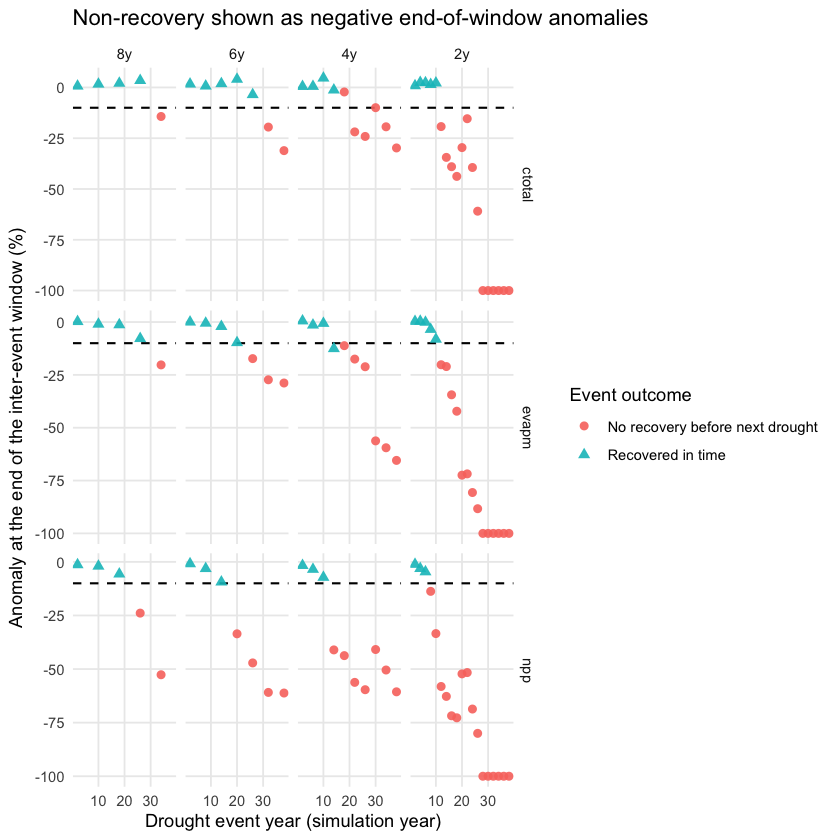

In [150]:
library(dplyr)
library(ggplot2)

# --- User-defined recovery threshold used in your analysis ---
threshold_pct <- -10

# rec_events must exist in your environment (event-level table)
# Columns expected: Scenario, Variable, event_year, end_year, censored, end_anomaly

rec_events_plot <- rec_events %>%
  mutate(
    Scenario = factor(Scenario, levels = c("8y","6y","4y","2y")),
    status = ifelse(censored, "No recovery before next drought", "Recovered in time")
  )

ggplot(rec_events_plot, aes(x = event_year, y = end_anomaly, shape = status, color = status)) +
  geom_hline(yintercept = threshold_pct, linetype = "dashed", linewidth = 0.6) +
  geom_point(size = 2.2, alpha = 0.9) +
  facet_grid(Variable ~ Scenario, scales = "free_y") +
  labs(
    x = "Drought event year (simulation year)",
    y = "Anomaly at the end of the inter-event window (%)",
    title = "Non-recovery shown as negative end-of-window anomalies",
    shape = "Event outcome",
    color = "Event outcome"
  ) +
  theme_minimal() +
  theme(panel.grid.minor = element_blank())


In [151]:


# --- Optional: enforce a meaningful scenario order ---
scenario_levels <- c("regclim", "8y", "6y", "4y", "2y")

rec_summary <- rec_summary %>%
  mutate(
    Scenario = factor(Scenario, levels = scenario_levels),
    Variable = factor(Variable)
  )

# --- Heatmap of non-recovery frequency (censored_rate) ---
ggplot(rec_summary, aes(x = Scenario, y = Variable, fill = censored_rate)) +
  geom_tile(color = "white") +
  labs(
    x = "Scenario (drought recurrence)",
    y = "Variable",
    fill = "No recovery\nbefore next drought",
    title = "Frequency of non-recovery across drought events"
  ) +
  theme_minimal() +
  theme(panel.grid = element_blank())


ERROR while rich displaying an object: Error in `geom_tile()`:
! Problem while computing aesthetics.
i Error occurred in the 1st layer.
Caused by error:
! objeto 'censored_rate' n~ao encontrado

Traceback:
1. sapply(x, f, simplify = simplify)
2. lapply(X = X, FUN = FUN, ...)
3. FUN(X[[i]], ...)
4. tryCatch(withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.null(rpr)) 
 .         return(NULL)
 .     prepare_content(is.raw(rpr), rpr)
 . }, error = error_handler), error = outer_handler)
5. tryCatchList(expr, classes, parentenv, handlers)
6. tryCatchOne(expr, names, parentenv, handlers[[1L]])
7. doTryCatch(return(expr), name, parentenv, handler)
8. withCallingHandlers({
 .     if (!mime %in% names(repr::mime2repr)) 
 .         stop("No repr_* for mimetype ", mime, " in repr::mime2repr")
 .     rpr <- repr::mime2repr[[mime]](obj)
 .     if (is.nu